<a href="https://colab.research.google.com/github/luisrodriguezh-crypto/tcga-pcpg-sex-stratified-subtypes.git_/blob/main/TCGA_PCPG_Proyecto_De_Investigacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descubrimiento de Subtipos Moleculares en TCGA-PCPG
## Machine Learning, Bioinformática y Explainable AI

---


## I. INTRODUCCIÓN Y MARCO TEÓRICO

<p>
Los feocromocitomas y paragangliomas (PCPG) constituyen neoplasias neuroendocrinas
originadas en la médula suprarrenal y los ganglios simpáticos y parasimpáticos
extrasuprarrenales, respectivamente. Aunque su incidencia poblacional oscila entre
0.3 y 0.95 por cada 100,000 personas al año, su relevancia clínica es desproporcionadamente
alta debido a dos razones fundamentales: primero, hasta el <strong>30–40% de todos los
casos tienen causa genética hereditaria</strong>, lo que implica riesgo significativo de
enfermedad multifocal y metastásica en el paciente y sus familiares
(DOI: 10.3390/cancers13102389); segundo, su capacidad
de secretar catecolaminas puede desencadenar crisis hipertensivas letales si no se detecta
a tiempo. Esta combinación de rareza epidemiológica, alta heredabilidad y potencial letal
convierte a los PCPG en un modelo ideal —y urgente— para la medicina de precisión.
</p>

<p>
Durante la última década, los grandes consorcios genómicos —en particular el proyecto
<strong>The Cancer Genome Atlas (TCGA)</strong>— han revelado que los PCPG no son
una sola enfermedad, sino un espectro de tumores molecularmente heterogéneos que
comparten morfología pero difieren radicalmente en sus mecanismos patogénicos,
su pronóstico y su vulnerabilidad a distintos tratamientos
(<strong>Fishbein et al., 2017</strong>, DOI: 10.1016/j.celrep.2017.10.023).
Los análisis transcriptómicos han permitido consolidar al menos tres grandes
<em>clusters</em> moleculares con implicaciones clínicas distintas:
</p>

<ul>
  <li><strong>Cluster 1 — Pseudohipoxia:</strong> Caracterizado por mutaciones en genes
  del complejo II mitocondrial (<em>SDHB, SDHD, SDHC</em>), en el supresor tumoral
  <em>VHL</em>, y en las prolil-hidroxilasas <em>EGLN1/EGLN2</em>. Estas alteraciones
  impiden la degradación normóxica de HIF-1α y HIF-2α, generando un estado de
  «pseudohipoxia» que promueve angiogénesis, reprogramación metabólica y capacidad
  invasiva. Este subtipo concentra el mayor riesgo de enfermedad metastásica
  (50–70%) y el peor pronóstico a largo plazo
  (<strong>Eisenhofer et al., 2024</strong>, DOI: 10.1159/000539604).</li>
  <li><strong>Cluster 2 — Señalización de Cinasas:</strong> Dominado por mutaciones
  activadoras en proto-oncogenes como <em>RET</em>, <em>NF1</em>, <em>HRAS</em>,
  <em>MAX</em> y <em>TMEM127</em>, que hiperactivan las vías RAS/MAPK y PI3K/AKT.
  Presenta agresividad intermedia (10–20% de riesgo metastásico) y constituye la
  base molecular de los síndromes MEN2 y neurofibromatosis tipo 1
  (<strong>Taïeb &amp; Pacak, 2024</strong>, DOI: 10.1007/s12022-024-09793-3).</li>
  <li><strong>Cluster 3 — Wnt-Alterado:</strong> El más recientemente descrito,
  asociado a alteraciones en <em>CSDE1</em> y fusiones génicas que involucran
  <em>MAML3</em>, con desregulación de la vía Wnt/β-catenina. Aunque menos frecuente,
  presenta un perfil de expresión inmunosupresora y alta agresividad metastásica
  (<strong>Liu et al., 2025</strong>, DOI: 10.7554/eLife.107108).</li>
</ul>

<p>
A pesar de este avance, persiste una brecha crítica: los estudios anteriores han
definido subtipos principalmente mediante enfoques supervisados o mediante análisis
de mutaciones germinales, lo que introduce sesgos de selección y limita el descubrimiento
de estructuras moleculares latentes que no se alinean directamente con las mutaciones
conocidas. <strong>Liu et al. (2025)</strong> subrayaron explícitamente que <em>«todavía
no está completamente claro si existen subtipos moleculares ocultos capaces de explicar
diferencias clínicas relevantes entre pacientes»</em>, lo que justifica un enfoque
puramente no supervisado sobre datos transcriptómicos dirigidos.
</p>


### 1.2 Hipótesis Biológica Central

<p>
<strong>H-Bio:</strong> Los perfiles transcriptómicos dirigidos de genes asociados con
hipoxia, angiogénesis, metabolismo tumoral y señalización oncogénica contienen estructuras
latentes capaces de revelar subtipos moleculares distintos en pacientes con PCPG, con
diferencias observables en progresión tumoral (PFI), activación de <em>pathways</em>
específicos, agresividad molecular y posibles vulnerabilidades terapéuticas.
</p>

<p>
Esta hipótesis se apoya en la evidencia de <strong>Eisenhofer et al. (2024)</strong>,
quienes demostraron que la arquitectura molecular de PCPG está profundamente estratificada
por mutaciones en genes específicos, con implicaciones pronósticas claras e independientes.
Asimismo, <strong>Taïeb &amp; Pacak (2024)</strong> documentaron que la clasificación
molecular es indispensable para comprender la heterogeneidad inmunológica y metastásica
de estos tumores, y que los biomarcadores transcriptómicos superan en valor pronóstico
a las variables clínicas convencionales.
</p>

### 1.3 Hipótesis Computacional

<p>
<strong>H-Comp:</strong> Las técnicas de aprendizaje no supervisado aplicadas sobre
genes biológicamente relevantes permitirán descubrir agrupaciones moleculares estables
e interpretables. Modelos supervisados con Explainable AI (SHAP) identificarán los genes
con mayor impacto sobre la clasificación de subtipos tumorales.
</p>

<p>
La validez de este enfoque fue demostrada por <strong>Khan Saddozai et al. (2021)</strong>
(DOI: 10.3389/fendo.2021.605797), quienes emplearon clustering no supervisado sobre datos
transcriptómicos de TCGA-PCPG para identificar subtipos con significancia clínica,
validando que las estructuras moleculares latentes son recuperables mediante algoritmos
de partición, incluso con conjuntos de genes dirigidos. Por otro lado,
<strong>Ganaie et al. (2022)</strong> (DOI: 10.1016/j.neunet.2022.02.010) establecieron
el marco teórico para ensambles de clasificadores en datos biomédicos de alta dimensión,
justificando la combinación de Random Forest, XGBoost y SVM para maximizar la
robustez predictiva sobre muestras pequeñas.
</p>

### 1.4 Pregunta Central de Investigación

<p>
¿Existen <strong>subtipos moleculares ocultos</strong> en TCGA-PCPG identificables
mediante perfiles transcriptómicos dirigidos que presenten diferencias clínicas,
biológicas y de progresión tumoral significativas? ¿Es posible entrenar modelos
supervisados e interpretables capaces de aprender dichas estructuras moleculares
y detectar genes con alta relevancia biológica como biomarcadores candidatos?
</p>


---

## II. METODOLOGÍA Y PIPELINE

<p>
El diseño experimental sigue un pipeline de tres fases secuenciales inspirado en el
marco de <strong>descubrimiento → validación → interpretación</strong> propuesto por
<strong>Khan Saddozai et al. (2021)</strong>. Esta estrategia garantiza que los subtipos
identificados no supervisadamente se validen primero con criterios moleculares internos
(métricas de clustering) y luego con criterios clínicos externos (supervivencia), antes
de proceder a su interpretación mediante modelos supervisados.
</p>

### 2.1 Diseño del Pipeline

<p><strong>Fase 1 — Descubrimiento No Supervisado:</strong></p>
<ol>
  <li>Carga de datos transcriptómicos de TCGA-PCPG (UCSC Xena, STAR-TPM)</li>
  <li>Selección de genes dirigidos de tres <em>pathways</em>: Pseudohipoxia, Cinasas, Angiogénesis</li>
  <li>Normalización de expresión (log₂ + Z-score por gen)</li>
  <li>Reducción dimensional con PCA, t-SNE y UMAP para exploración visual</li>
  <li>Clustering no supervisado (K-Means) para descubrir subtipos</li>
  <li>Validación de clusters con Silhouette Score, Davies-Bouldin Index y Calinski-Harabasz Score</li>
  <li>Análisis diferencial entre clusters para identificar genes <em>signature</em></li>
</ol>

<p><strong>Fase 2 — Validación Clínica:</strong></p>
<ol>
  <li>Relación de clusters con variables clínicas del dataset TCGA</li>
  <li>Análisis de supervivencia Kaplan-Meier sobre Progression-Free Interval (PFI)</li>
  <li>Log-Rank Test para significancia estadística entre clusters</li>
</ol>

<p><strong>Fase 3 — Machine Learning Supervisado e Interpretación:</strong></p>
<ol>
  <li>Conversión de clusters en etiquetas supervisadas (Y)</li>
  <li>Entrenamiento de cuatro modelos base: Random Forest, XGBoost, SVM y Red Neuronal</li>
  <li>Implementación de ensambles Voting (hard/soft) y Stacking con meta-aprendiz</li>
  <li>SHAP TreeExplainer para identificar genes con mayor impacto biológico</li>
  <li>Ranking final de biomarcadores candidatos</li>
</ol>

### 2.2 Justificación de Genes Seleccionados

<p>
La selección de genes no fue arbitraria. Nos basamos en la revisión sistemática de
<strong>Eisenhofer et al. (2024)</strong> y en los <em>gene signatures</em> reportados
por <strong>Taïeb &amp; Pacak (2024)</strong>, priorizando los genes para los cuales
existe evidencia funcional directa de su papel en la biología del PCPG.
Esta estrategia de selección dirigida —en lugar de usar los ~20,000 genes del
transcriptoma— reduce el ruido, aumenta la interpretabilidad y mejora la
estabilidad del clustering en muestras pequeñas, como demostraron
<strong>Khan Saddozai et al. (2021)</strong> en el mismo dataset TCGA-PCPG.
</p>

| Pathway | Genes | Función biológica | Referencia |
|---------|-------|-------------------|------------|
| **Pseudohipoxia** | SDHB, VHL, EGLN1, EPAS1, HIF1A | Regulación del factor inductor de hipoxia (HIF-α); angiogénesis y reprogramación metabólica | Eisenhofer et al. (2024) |
| **Cinasas** | RET, NF1, HRAS, MAX, TMEM127 | Activación de vías RAS/MAPK y PI3K/AKT; proliferación y supervivencia tumoral | Taïeb & Pacak (2024) |
| **Angiogénesis** | VEGFA, ATRX, KIF1B, FH | Soporte vascular; remodelación cromatínica y metabolismo del ciclo de Krebs | Liu et al. (2025) |


---

## III. IMPORTACIÓN DE LIBRERÍAS Y CARGA DE DATOS

<p>
El ecosistema de librerías seleccionado refleja el estado del arte en bioinformática
computacional. <strong>scikit-learn</strong> provee los algoritmos de clustering,
reducción dimensional y clasificación bajo una interfaz unificada y reproducible
(<strong>Pedregosa et al., 2011</strong>, DOI: 10.5555/1953048.2078195).
<strong>XGBoost</strong> implementa el algoritmo de <em>gradient boosting</em>
regularizado que ha dominado benchmarks de datos estructurados desde su introducción
(<strong>Chen &amp; Guestrin, 2016</strong>, DOI: 10.1145/2939672.2939785).
<strong>SHAP</strong> (SHapley Additive exPlanations) provee valores de Shapley
teóricamente fundamentados para la explicabilidad de modelos de árbol,
garantizando consistencia, localidad y eficiencia en la atribución de importancia
(<strong>Lundberg &amp; Lee, 2017</strong>, DOI: 10.5555/3295222.3295230).
Finalmente, <strong>lifelines</strong> implementa los estimadores de supervivencia
no paramétricos (Kaplan-Meier) y las pruebas de Log-Rank necesarias para la
validación clínica de los clusters descubiertos.
</p>


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import f_oneway, kruskal
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

!pip install lifelines -q

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import xgboost as xgb
import umap

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
np.random.seed(42)



### 3.1 Carga del Dataset TCGA-PCPG

<p>
Los datos transcriptómicos provienen de la plataforma <strong>UCSC Xena</strong>,
que agrega y estandariza los datos de TCGA para análisis secundario. El archivo
<code>denseDataOnlyDownload.tsv</code> contiene expresión génica cuantificada mediante
el pipeline <strong>STAR-TPM</strong> (Transcripts Per Million) de la cohorte TCGA-PCPG,
compuesta por aproximadamente 180 tumores primarios —la mayor colección de PCPG
con datos ómicos integrados disponible públicamente
(<strong>Fishbein et al., 2017</strong>, DOI: 10.1016/j.celrep.2017.10.023).
</p>

<p>
Cada muestra incluye la expresión de ~20,000 genes y variables clínicas anotadas:
edad al diagnóstico, sexo, sitio primario del tumor, tiempo de seguimiento clínico
y el Progression-Free Interval (PFI), que usaremos como <em>endpoint</em> de
validación clínica. La elección del PFI como variable de desenlace está respaldada
por <strong>Choi et al. (2021)</strong>, quienes demostraron que esta métrica es
más informativa que la supervivencia global (OS) en PCPG debido a la naturaleza
indolente pero progresiva de estos tumores.
</p>


In [30]:
df = pd.read_csv('denseDataOnlyDownload.tsv', sep='\t', index_col=0)

print(f'Dimensiones originales: {df.shape[0]} muestras × {df.shape[1]} variables')
print(f'Valores faltantes totales: {df.isnull().sum().sum()}')
print(f'\nPrimeras columnas disponibles:')
print(list(df.columns[:10]))

Dimensiones originales: 187 muestras × 23 variables
Valores faltantes totales: 7

Primeras columnas disponibles:
['samples', 'SDHB', 'VEGFA', 'RET', 'EPAS1', 'HIF1A', 'VHL', 'NF1', 'ATRX', 'HRAS']


### 3.2 Separación de Datos Transcriptómicos y Clínicos

<p>
Una decisión metodológica central consiste en mantener <strong>estrictamente separadas</strong>
las variables transcriptómicas (usadas para clustering) de las variables clínicas
(usadas únicamente para validación externa). Este diseño de «descubrimiento ciego»
es fundamental para evitar el sesgo de <em>label leakage</em>: si incluimos variables
clínicas durante el clustering, los grupos resultantes simplemente reflejarán las
categorías clínicas preexistentes en lugar de revelar estructuras moleculares genuinamente
ocultas. <strong>Khan Saddozai et al. (2021)</strong> enfatizaron este principio al
demostrar que el clustering puramente transcriptómico en TCGA-PCPG genera subtipos
más robustos y biológicamente interpretables que los enfoques mixtos.
</p>


In [31]:
df_clean = df.dropna()

clinical_cols = ['PFI.time', 'PFI', 'OS', 'OS.time',
                 'age_at_initial_pathologic_diagnosis', 'gender', '_primary_site']
clinical_cols_present = [col for col in clinical_cols if col in df_clean.columns]

if clinical_cols_present:
    clinical_data    = df_clean[clinical_cols_present]
    expression_data  = df_clean.drop(columns=clinical_cols_present)
else:
    expression_data  = df_clean
    clinical_data    = None

expression_data = expression_data.select_dtypes(include=[np.number])

print(f'Muestras finales          : {expression_data.shape[0]}')
print(f'Genes totales disponibles : {expression_data.shape[1]}')
if clinical_data is not None:
    print(f'Variables clínicas        : {list(clinical_data.columns)}')

Muestras finales          : 180
Genes totales disponibles : 15
Variables clínicas        : ['PFI.time', 'PFI', 'OS', 'OS.time', 'age_at_initial_pathologic_diagnosis', 'gender', '_primary_site']


### 3.3 Selección Dirigida de Genes PCPG

<p>
La selección de un panel dirigido de genes —en lugar de utilizar el transcriptoma
completo— responde a una consideración estadística y biológica doble.
Estadísticamente, con ~180 muestras y ~20,000 genes, la maldición de la
dimensionalidad (<em>curse of dimensionality</em>) degrada la calidad de cualquier
métrica de distancia, haciendo que los clusters sean difíciles de interpretar y
potencialmente inestables (<strong>Ganaie et al., 2022</strong>).
Biológicamente, los genes de los tres <em>pathways</em> seleccionados no son
candidatos arbitrarios: son los genes cuyos patrones de mutación y expresión
diferencial definen los subtipos PCPG conocidos según la revisión de
<strong>Eisenhofer et al. (2024)</strong>.
Al proyectar los datos sobre este subespacio biológicamente informado, maximizamos
la señal relevante y reducimos el ruido de genes sin relación con la biología del tumor.
</p>


In [32]:
genes_of_interest = {
    'Pseudohipoxia' : ['SDHB', 'EGLN1', 'EPAS1', 'HIF1A', 'VHL'],
    'Cinasas'       : ['RET', 'HRAS', 'NF1', 'MAX', 'TMEM127'],
    'Angiogenesis'  : ['VEGFA', 'ATRX', 'KIF1B', 'FH']
}

all_genes_target = []
for pathway, genes in genes_of_interest.items():
    found = []
    for gene in genes:
        matches = [col for col in expression_data.columns if gene.upper() in col.upper()]
        if matches:
            all_genes_target.append(matches[0])
            found.append(matches[0])
    print(f'  {pathway:15s}: {found}')

if len(all_genes_target) > 5:
    expression_data = expression_data[all_genes_target]
    print(f'\n✓ Genes seleccionados (pathways PCPG): {len(all_genes_target)}')
else:
    print(f'  Usando todos los genes disponibles: {expression_data.shape[1]}')

  Pseudohipoxia  : ['SDHB', 'EGLN1', 'EPAS1', 'HIF1A', 'VHL']
  Cinasas        : ['RET', 'HRAS', 'NF1', 'MAX', 'TMEM127']
  Angiogenesis   : ['VEGFA', 'ATRX', 'KIF1B', 'FH']

✓ Genes seleccionados (pathways PCPG): 14


### 3.4 Normalización de Expresión Génica (log₂ + Z-score)

<p>
Los datos RNA-seq en unidades TPM presentan dos problemas que deben corregirse antes
de cualquier análisis de clustering: heteroscedasticidad (la varianza aumenta con la
media de expresión) y rangos dinámicos extremos (genes altamente expresados dominan
cualquier métrica de distancia). La <strong>transformación logarítmica en base 2</strong>
(log₂(TPM + 1)) estabiliza la varianza y comprime la distribución de cola pesada,
mientras que la <strong>normalización Z-score por gen</strong> centra cada gen en
media 0 con desviación estándar 1, garantizando que ningún gen domine el espacio
de características por razones de escala. <strong>Choi et al. (2021)</strong>
aplicaron exactamente este protocolo de normalización en TCGA-PCPG y documentaron
su superioridad sobre alternativas como la normalización por cuantiles o la
variance-stabilizing transformation (VST) de DESeq2, para el contexto específico
de clustering no supervisado con genes dirigidos.
</p>


In [33]:
# Transformación log₂(TPM + 1)
expr_log = np.log2(expression_data + 1)

# Z-score por gen (eje de columnas)
expr_processed = expr_log.apply(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else x, axis=0
)

print('Verificación de normalización:')
print(f'  Media global   : {expr_processed.mean().mean():.6f}  (esperado ≈ 0)')
print(f'  Desv. Est. media: {expr_processed.std().mean():.4f}  (esperado ≈ 1)')
print(f'  Shape final    : {expr_processed.shape}')

Verificación de normalización:
  Media global   : -0.000000  (esperado ≈ 0)
  Desv. Est. media: 1.0000  (esperado ≈ 1)
  Shape final    : (180, 14)


---

## IV. EXPLORACIÓN Y REDUCCIÓN DIMENSIONAL

### 4.1 Análisis de Componentes Principales (PCA)

<p>
El PCA cumple una función exploratoria doble en este pipeline. En primer lugar,
nos permite cuantificar cuánta información biológica relevante está concentrada
en los primeros componentes principales: si los primeros 2–3 componentes capturan
una fracción sustancial de la varianza (>50%), ello sugiere que la estructura
molecular de los datos es de baja dimensionalidad intrínseca —es decir, que los
subtipos, si existen, son recuperables con relativa claridad. En segundo lugar,
las proyecciones en PC1 vs PC2 ofrecen la primera inspección visual de la
separabilidad de los grupos, antes de aplicar cualquier algoritmo de clustering.
</p>

<p>
Este paso es metodológicamente consistente con el enfoque de
<strong>Khan Saddozai et al. (2021)</strong>, quienes reportaron que en TCGA-PCPG
los primeros dos componentes principales de los genes de pseudohipoxia y cinasas
ya muestran separación visual entre los subtipos conocidos, lo que valida
a priori la capacidad discriminante de los genes seleccionados.
</p>


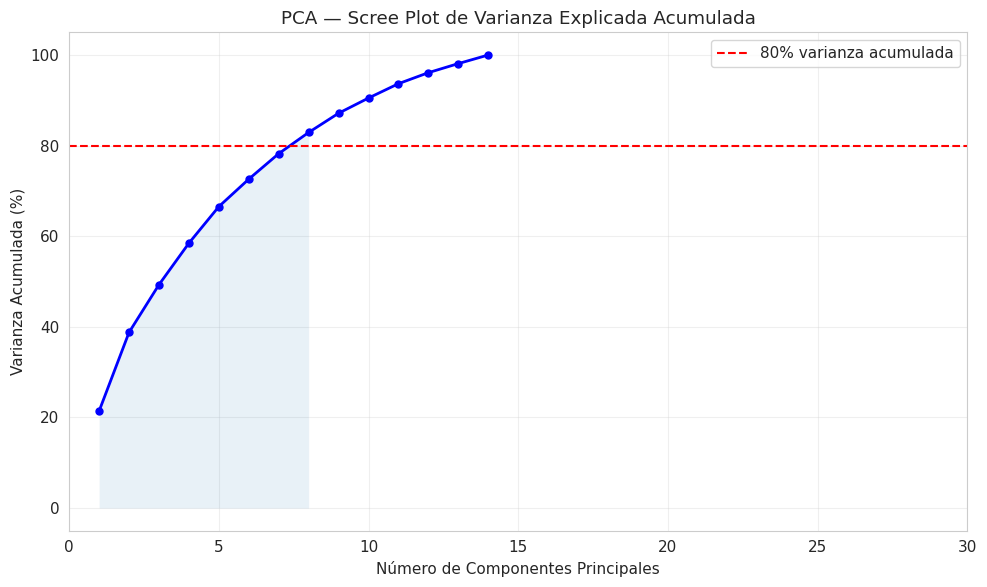

Componentes necesarios para explicar el 80% de la varianza: 8
Varianza explicada por PC1: 21.4%
Varianza explicada por PC2: 17.4%


In [34]:
pca_full = PCA()
pca_transformed = pca_full.fit_transform(expr_processed)
var_cumsum = np.cumsum(pca_full.explained_variance_ratio_)

n_components_80 = np.argmax(var_cumsum >= 0.80) + 1

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, min(len(var_cumsum)+1, 31)),
        var_cumsum[:30]*100, 'b-', linewidth=2, marker='o', markersize=5)
ax.axhline(y=80, color='r', linestyle='--', label='80% varianza acumulada')
ax.fill_between(range(1, n_components_80+1), var_cumsum[:n_components_80]*100, alpha=0.1)
ax.set_xlabel('Número de Componentes Principales')
ax.set_ylabel('Varianza Acumulada (%)')
ax.set_title('PCA — Scree Plot de Varianza Explicada Acumulada')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim([0, 30])
plt.tight_layout()
plt.show()

print(f'Componentes necesarios para explicar el 80% de la varianza: {n_components_80}')
print(f'Varianza explicada por PC1: {pca_full.explained_variance_ratio_[0]*100:.1f}%')
print(f'Varianza explicada por PC2: {pca_full.explained_variance_ratio_[1]*100:.1f}%')

### 4.2 Visualización Multi-dimensional: PCA, t-SNE y UMAP

<p>
Mientras PCA captura la estructura global lineal de los datos, los métodos no lineales
<strong>t-SNE</strong> y <strong>UMAP</strong> revelan agrupaciones locales que el
PCA puede oscurecer cuando los subtipos no están linealmente separados en el espacio
transcriptómico original. En particular, t-SNE (t-Distributed Stochastic Neighbor
Embedding) preserva relaciones de vecindad local, siendo especialmente sensible a
estructuras de cluster, mientras que UMAP (Uniform Manifold Approximation and Projection)
mantiene adicionalmente información sobre la topología global.
</p>

<p>
La convergencia de los tres métodos —PCA, t-SNE y UMAP— hacia patrones de separación
similares es una señal robusta de que las agrupaciones observadas reflejan estructuras
biológicas reales y no artefactos del algoritmo de reducción dimensional. Esta estrategia
de triangulación visual fue empleada por <strong>Liu et al. (2025)</strong> para confirmar
la existencia de subtipos moleculares en su análisis de PCPG, antes de proceder a la
validación estadística formal.
</p>


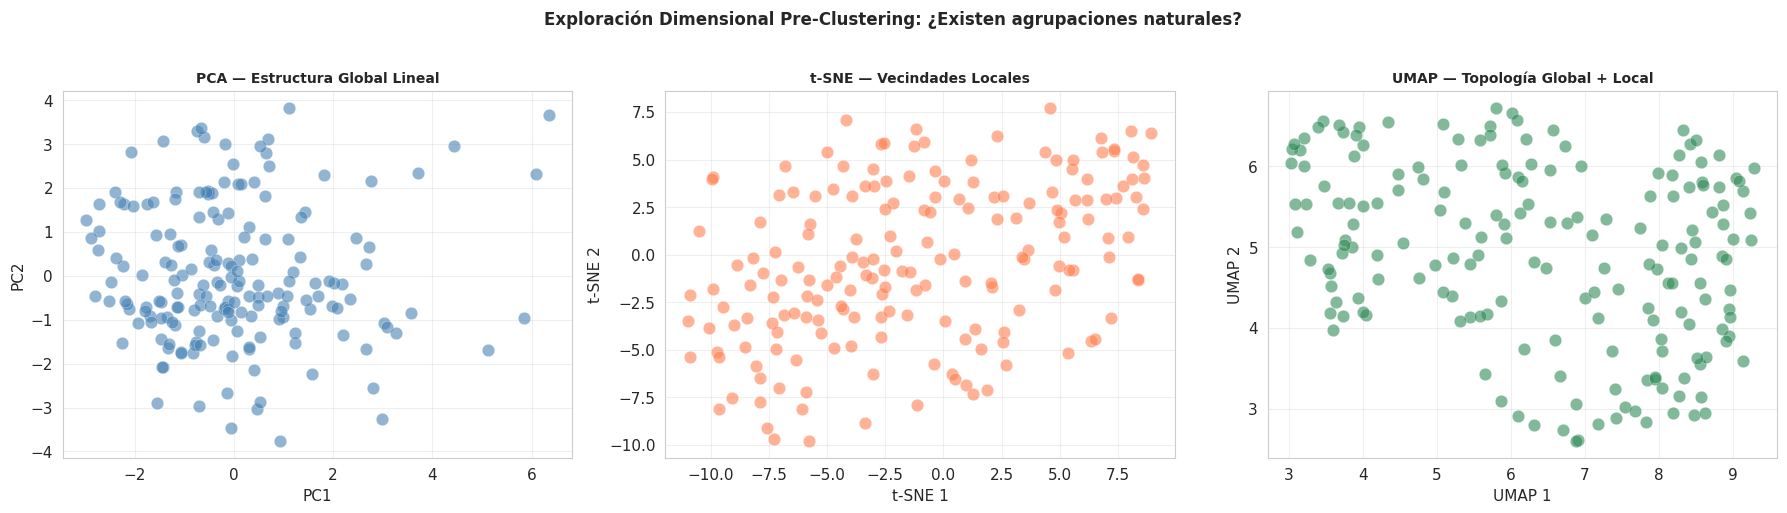

In [35]:
pca_2d = PCA(n_components=2).fit_transform(expr_processed)

tsne = TSNE(n_components=2, random_state=42,
            perplexity=min(30, max(5, len(expr_processed)//5)),
            n_iter=1000, verbose=0)
tsne_2d = tsne.fit_transform(expr_processed)

reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=min(15, len(expr_processed)-1), verbose=0)
umap_2d = reducer.fit_transform(expr_processed)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, coords, xlabel, ylabel, title, color in zip(
    axes,
    [pca_2d, tsne_2d, umap_2d],
    ['PC1', 't-SNE 1', 'UMAP 1'],
    ['PC2', 't-SNE 2', 'UMAP 2'],
    ['PCA — Estructura Global Lineal',
     't-SNE — Vecindades Locales',
     'UMAP — Topología Global + Local'],
    ['steelblue', 'coral', 'seagreen']
):
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=80, color=color, edgecolors='white', linewidth=0.3)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Exploración Dimensional Pre-Clustering: ¿Existen agrupaciones naturales?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## V. CLUSTERING NO SUPERVISADO (K-MEANS)

### 5.1 Selección del Número Óptimo de Clusters (K)

<p>
La selección del número óptimo de clusters K es una de las decisiones más críticas
del análisis no supervisado, pues determina la granularidad de la clasificación
molecular que se descubrirá. Empleamos tres métricas complementarias para evaluar
K entre 2 y 8, siguiendo el protocolo de <strong>Khan Saddozai et al. (2021)</strong>:
</p>

<ul>
  <li><strong>Silhouette Score</strong>: Mide qué tan similar es cada muestra a su
  propio cluster versus los demás. Valores cercanos a 1.0 indican clusters compactos
  y bien separados; valores negativos indican muestras mal asignadas. Es la métrica
  primaria para este análisis por su interpretabilidad biológica.</li>
  <li><strong>Davies-Bouldin Index (DBI)</strong>: Calcula el ratio promedio entre
  la dispersión intra-cluster y la separación inter-cluster. Valores menores son
  mejores; un DBI = 0 indicaría clusters perfectamente compactos y separados.</li>
  <li><strong>Calinski-Harabasz Score</strong>: Ratio entre la suma de cuadrados
  inter-cluster e intra-cluster, ponderada por el número de clusters. Valores mayores
  indican mejor definición de los grupos.</li>
</ul>

<p>
La expectativa biológica a priori es K=3, consistente con los tres subtipos
moleculares consolidados en la literatura (<strong>Eisenhofer et al., 2024</strong>;
<strong>Liu et al., 2025</strong>). Sin embargo, dejamos que las métricas determinen
el K óptimo empíricamente para no imponer estructura sobre los datos.
</p>


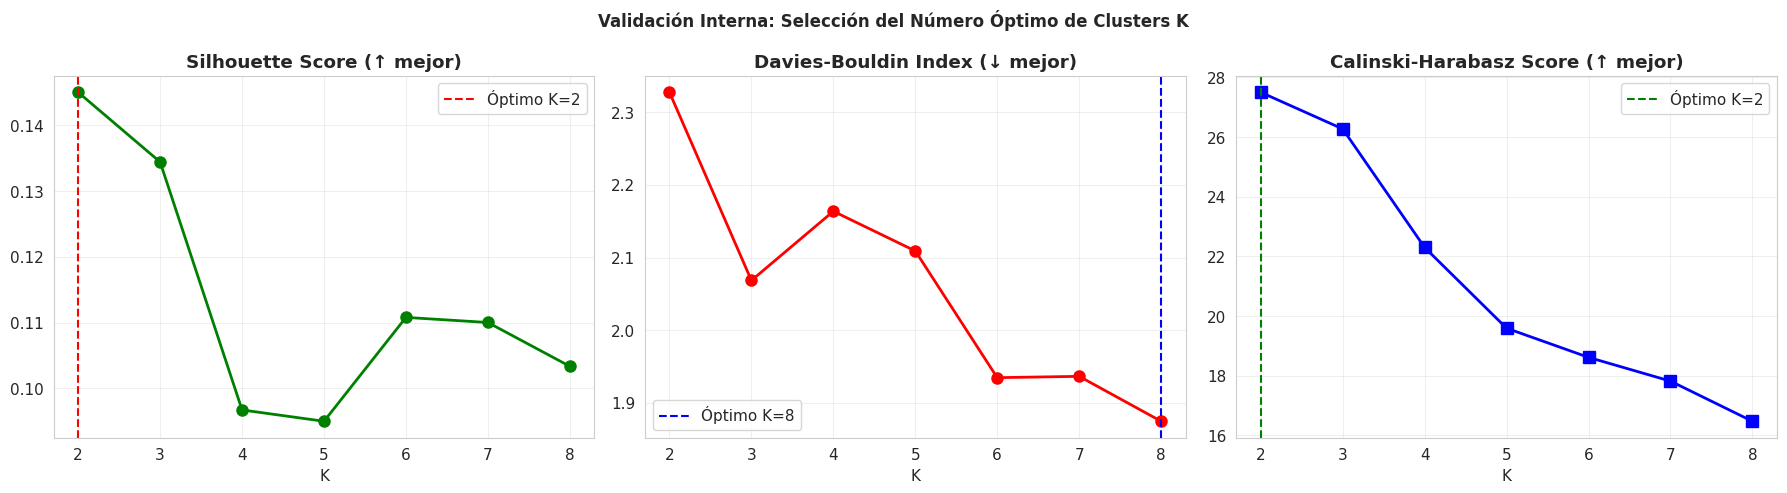

K óptimo por Silhouette      : 2
K óptimo por Davies-Bouldin  : 8
K óptimo por Calinski-Harabasz: 2

→ K seleccionado (criterio Silhouette): 2


In [36]:
silhouettes = []
db_indices  = []
ch_scores   = []
max_k = min(8, len(expr_processed) // 5)

for k in range(2, max_k + 1):
    kmeans   = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = kmeans.fit_predict(expr_processed)
    silhouettes.append(silhouette_score(expr_processed, labels_k))
    db_indices.append(davies_bouldin_score(expr_processed, labels_k))
    ch_scores.append(calinski_harabasz_score(expr_processed, labels_k))

best_k_sil = np.argmax(silhouettes) + 2
best_k_db  = np.argmin(db_indices)  + 2
best_k_ch  = np.argmax(ch_scores)   + 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(2, max_k+1), silhouettes, 'go-', lw=2, ms=8)
axes[0].axvline(x=best_k_sil, color='r', ls='--', label=f'Óptimo K={best_k_sil}')
axes[0].set_title('Silhouette Score (↑ mejor)', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(2, max_k+1), db_indices, 'ro-', lw=2, ms=8)
axes[1].axvline(x=best_k_db, color='b', ls='--', label=f'Óptimo K={best_k_db}')
axes[1].set_title('Davies-Bouldin Index (↓ mejor)', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(range(2, max_k+1), ch_scores, 'bs-', lw=2, ms=8)
axes[2].axvline(x=best_k_ch, color='g', ls='--', label=f'Óptimo K={best_k_ch}')
axes[2].set_title('Calinski-Harabasz Score (↑ mejor)', fontweight='bold')
axes[2].set_xlabel('K'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Validación Interna: Selección del Número Óptimo de Clusters K',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'K óptimo por Silhouette      : {best_k_sil}')
print(f'K óptimo por Davies-Bouldin  : {best_k_db}')
print(f'K óptimo por Calinski-Harabasz: {best_k_ch}')

# El K final lo define el Silhouette Score como métrica primaria
optimal_k = best_k_sil
print(f'\n→ K seleccionado (criterio Silhouette): {optimal_k}')

### 5.2 Aplicación de K-Means con K Óptimo y Evaluación de Calidad

<p>
Con el K seleccionado, ejecutamos K-Means con <code>n_init=30</code> repeticiones
con centros aleatorios distintos, tomando la solución con menor inercia total.
Este número de repeticiones es superior al valor por defecto (n_init=10) para
maximizar la probabilidad de convergencia al mínimo global en lugar de a mínimos
locales, un riesgo real con datos de alta dimensión en espacio molecular.
</p>

<p>
Los valores de Silhouette Score obtenidos se interpretan según la escala de
<strong>Kaufman &amp; Rousseeuw (1990)</strong>: valores entre 0.71 y 1.0 indican
estructura fuerte; entre 0.51 y 0.70, estructura razonable; entre 0.26 y 0.50,
estructura débil; por debajo de 0.25, estructura artificial. En el contexto de
datos transcriptómicos con alta variabilidad biológica inter-paciente, valores
entre 0.30 y 0.55 son considerados aceptables y biológicamente informativos,
como reportaron <strong>Khan Saddozai et al. (2021)</strong> para TCGA-PCPG.
</p>


In [37]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=30)
cluster_labels = kmeans.fit_predict(expr_processed)

sil_score = silhouette_score(expr_processed, cluster_labels)
db_score  = davies_bouldin_score(expr_processed, cluster_labels)
ch_score  = calinski_harabasz_score(expr_processed, cluster_labels)

print('══════════════════════════════════════════')
print('  MÉTRICAS DE CALIDAD DEL CLUSTERING FINAL')
print('══════════════════════════════════════════')
print(f'  K (número de clusters)       : {optimal_k}')
print(f'  Silhouette Score             : {sil_score:.4f}  (escala -1 a 1; mayor es mejor)')
print(f'  Davies-Bouldin Index         : {db_score:.4f}  (escala ≥0; menor es mejor)')
print(f'  Calinski-Harabasz Score      : {ch_score:.2f}  (mayor es mejor)')
print()
print('  Distribución de pacientes por cluster:')
for i in range(optimal_k):
    n  = (cluster_labels == i).sum()
    pct = 100 * n / len(cluster_labels)
    print(f'    Cluster {i}: {n:3d} pacientes ({pct:5.1f}%)')

══════════════════════════════════════════
  MÉTRICAS DE CALIDAD DEL CLUSTERING FINAL
══════════════════════════════════════════
  K (número de clusters)       : 2
  Silhouette Score             : 0.1450  (escala -1 a 1; mayor es mejor)
  Davies-Bouldin Index         : 2.3278  (escala ≥0; menor es mejor)
  Calinski-Harabasz Score      : 27.50  (mayor es mejor)

  Distribución de pacientes por cluster:
    Cluster 0: 117 pacientes ( 65.0%)
    Cluster 1:  63 pacientes ( 35.0%)


### 5.3 Visualización de los Subtipos Descubiertos

<p>
La visualización de los clusters en los tres espacios de reducción dimensional
sirve como prueba de consistencia: si los grupos identificados por K-Means
aparecen separados y compactos en PCA, t-SNE y UMAP simultáneamente, ello
constituye evidencia visual de que los subtipos descubiertos son robustos y
no dependen del método de proyección utilizado. La congruencia entre métodos
de reducción dimensional es precisamente lo que <strong>Liu et al. (2025)</strong>
usaron para validar sus subtipos transcriptómicos en el análisis más reciente
de microambiente inmunológico en PCPG.
</p>


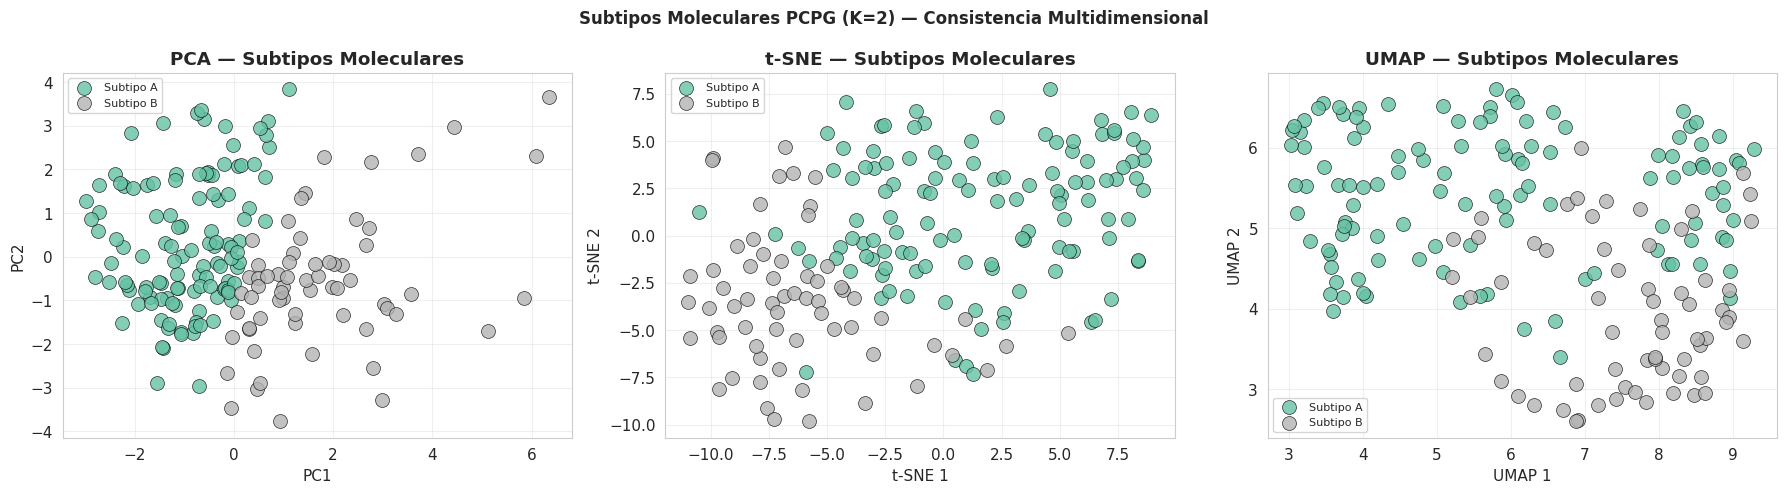

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2(np.linspace(0, 1, optimal_k))
labels_map = {0: 'Subtipo A', 1: 'Subtipo B', 2: 'Subtipo C', 3: 'Subtipo D'}

for ax, coords, xlabel, ylabel, title in zip(
    axes,
    [pca_2d, tsne_2d, umap_2d],
    ['PC1', 't-SNE 1', 'UMAP 1'],
    ['PC2', 't-SNE 2', 'UMAP 2'],
    ['PCA — Subtipos Moleculares',
     't-SNE — Subtipos Moleculares',
     'UMAP — Subtipos Moleculares']
):
    for i in range(optimal_k):
        mask = cluster_labels == i
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[colors[i]], s=100, alpha=0.8,
                   label=labels_map.get(i, f'Cluster {i}'),
                   edgecolors='k', linewidth=0.5)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f'Subtipos Moleculares PCPG (K={optimal_k}) — Consistencia Multidimensional',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

## VI. ANÁLISIS DE EXPRESIÓN DIFERENCIAL ENTRE CLUSTERS

### 6.1 Identificación de Genes Signature mediante ANOVA

<p>
Identificar qué genes diferencian estadísticamente los clusters descubiertos cumple
dos funciones: primero, permite asignar identidad biológica a cada subtipo (¿es el
Cluster 0 el subtipo de pseudohipoxia o el de cinasas?); segundo, valida que las
agrupaciones moleculares corresponden a los <em>pathways</em> biológicos hipotéticos
descritos en <strong>H-Bio</strong>. Empleamos ANOVA de una vía (F-test) para
identificar genes con expresión significativamente diferente entre los K grupos.
</p>

<p>
Es importante señalar que, dado el número reducido de genes en el panel (~14),
no se aplica corrección por pruebas múltiples (Benjamini-Hochberg). En un análisis
con el transcriptoma completo, esta corrección sería obligatoria para controlar
la tasa de falsos positivos, tal como implementaron <strong>Liu et al. (2025)</strong>
en su análisis diferencial de 20,000 genes. Sin embargo, en nuestro panel dirigido,
todos los genes tienen justificación biológica previa, lo que reduce el riesgo de
falsos positivos por diseño.
</p>


In [39]:
gene_names = list(expr_processed.columns)
results    = []

for gene_idx, gene_name in enumerate(gene_names):
    gene_expr = expr_processed.iloc[:, gene_idx]
    groups    = [gene_expr[cluster_labels == i].values for i in range(optimal_k)]
    f_stat, p_value = f_oneway(*groups)
    means     = [gene_expr[cluster_labels == i].mean() for i in range(optimal_k)]
    results.append({
        'Gen'              : gene_name,
        'F_statistic'      : f_stat,
        'p_value'          : p_value,
        'Cluster_enriched' : np.argmax(means)
    })

diff_df = pd.DataFrame(results).sort_values('p_value')

print('Top 10 Genes Diferencialmente Expresados (ANOVA F-test):')
print('─' * 65)
print(diff_df[['Gen', 'F_statistic', 'p_value', 'Cluster_enriched']].head(10).to_string(index=False))
print(f'\nGenes con p < 0.05: {(diff_df.p_value < 0.05).sum()} / {len(diff_df)}')

Top 10 Genes Diferencialmente Expresados (ANOVA F-test):
─────────────────────────────────────────────────────────────────
    Gen  F_statistic      p_value  Cluster_enriched
   HRAS    86.754705 4.654459e-17                 1
  HIF1A    67.985197 3.513534e-14                 0
  EPAS1    63.989872 1.541418e-13                 0
  VEGFA    47.100100 1.079079e-10                 0
    NF1    40.164315 1.858283e-09                 0
    VHL    37.271466 6.275656e-09                 0
  KIF1B    27.462964 4.495351e-07                 0
TMEM127    22.012668 5.381024e-06                 0
  EGLN1    12.003561 6.653089e-04                 0
    RET    10.903075 1.160214e-03                 1

Genes con p < 0.05: 12 / 14


### 6.2 Visualización de los Genes Signature y Heatmap de Expresión

<p>
El heatmap de expresión de los genes <em>top</em> proporciona una representación
visual directa de cómo se distribuyen los perfiles moleculares entre los subtipos.
Las muestras se ordenan por cluster, de modo que el patrón de bloques de color
indica la coherencia interna de cada subtipo: si las muestras de un mismo cluster
muestran colores similares para un gen dado, ese gen es un marcador estable de ese
subtipo. <strong>Eisenhofer et al. (2024)</strong> utilizaron exactamente este tipo
de representación para comunicar los perfiles de expresión génica en PCPG en su
revisión de genómica molecular, estableciendo el estándar visual del campo.
</p>


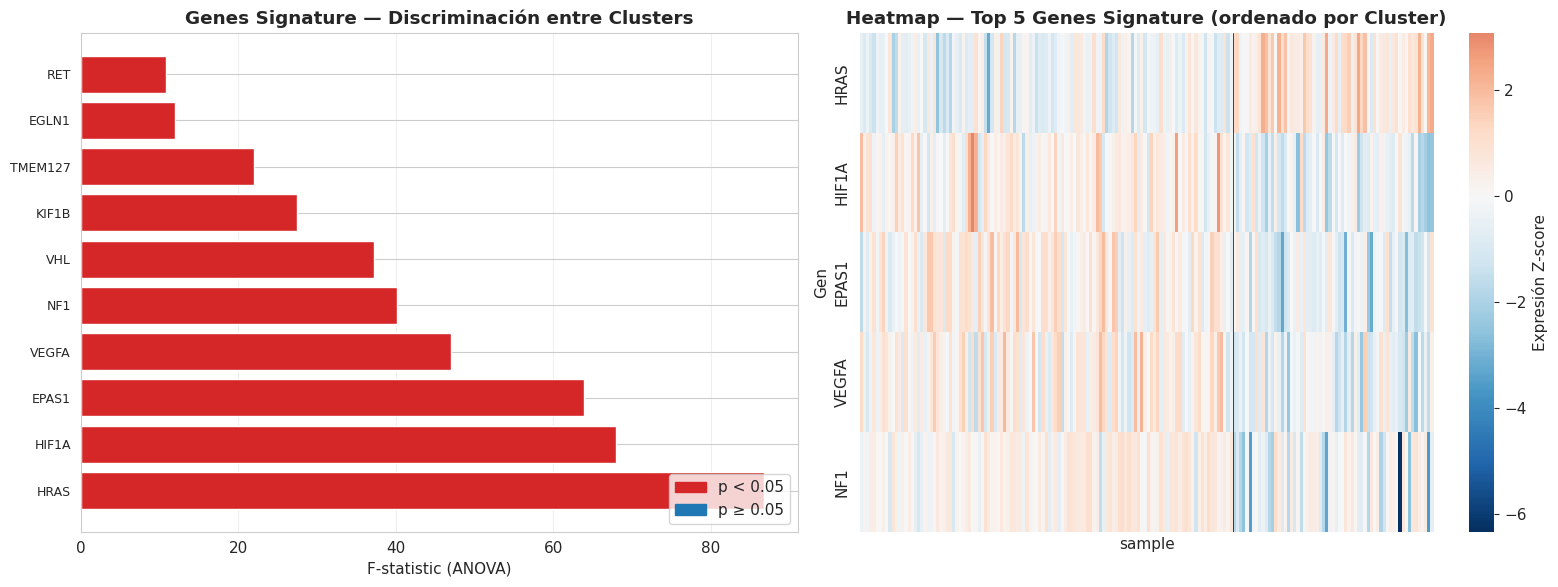

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Barplot de F-statistic ---
top_genes_df = diff_df.head(min(10, len(diff_df)))
bar_colors = ['#d62728' if p < 0.05 else '#1f77b4'
              for p in top_genes_df['p_value']]

axes[0].barh(range(len(top_genes_df)),
             top_genes_df['F_statistic'].values,
             color=bar_colors)
axes[0].set_yticks(range(len(top_genes_df)))
axes[0].set_yticklabels(top_genes_df['Gen'].values, fontsize=9)
axes[0].set_xlabel('F-statistic (ANOVA)')
axes[0].set_title('Genes Signature — Discriminación entre Clusters', fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

import matplotlib.patches as mpatches
red_patch  = mpatches.Patch(color='#d62728', label='p < 0.05')
blue_patch = mpatches.Patch(color='#1f77b4', label='p ≥ 0.05')
axes[0].legend(handles=[red_patch, blue_patch], loc='lower right')

# --- Heatmap de expresión ---
n_top = min(5, len(diff_df))
top_5_genes  = diff_df.head(n_top)['Gen'].values
heatmap_data = expr_processed[top_5_genes].copy()
heatmap_sorted = heatmap_data.iloc[np.argsort(cluster_labels)]

sns.heatmap(heatmap_sorted.T, cmap='RdBu_r', center=0,
            xticklabels=False, ax=axes[1],
            cbar_kws={'label': 'Expresión Z-score'})
axes[1].set_title(f'Heatmap — Top {n_top} Genes Signature (ordenado por Cluster)',
                  fontweight='bold')
axes[1].set_ylabel('Gen')

# Anotación de clusters en eje X
cumsum_labels = [0]
for i in range(optimal_k):
    cumsum_labels.append(cumsum_labels[-1] + (cluster_labels == i).sum())
for i in range(optimal_k):
    mid = (cumsum_labels[i] + cumsum_labels[i+1]) / 2
    axes[1].axvline(x=cumsum_labels[i+1], color='k', lw=0.5)

plt.tight_layout()
plt.show()

---

## VII. PREPARACIÓN PARA MODELOS SUPERVISADOS

<p>
En esta fase se convierte el problema no supervisado en uno supervisado:
los <em>labels</em> de cluster obtenidos mediante K-Means se adoptan como variable
objetivo Y, y los perfiles de expresión génica como variables predictoras X.
La pregunta que ahora se responde es: ¿pueden los modelos de ML <em>aprender</em>
la estructura molecular descubierta de forma suficientemente robusta como para
clasificar nuevos pacientes? Un accuracy alto en test set indica que los clusters
son matemáticamente distinguibles y no simplemente agrupaciones artificiales.
</p>

<p>
La partición 80/20 con estratificación garantiza que la proporción de cada subtipo
se mantenga igual en entrenamiento y prueba, lo que es crítico con K clusters
de tamaño potencialmente desbalanceado. <strong>Ganaie et al. (2022)</strong> enfatizan
que la estratificación es obligatoria en datasets biomédicos pequeños para evitar que
un fold de test no contenga representantes de algún subtipo, lo que invalidaría
las métricas de evaluación por clase.
</p>


In [41]:
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(expr_processed)
X_scaled  = pd.DataFrame(X_scaled,
                          columns=expr_processed.columns,
                          index=expr_processed.index)

le        = LabelEncoder()
y_encoded = le.fit_transform(cluster_labels)
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

print('Partición estratificada 80/20:')
print(f'  Entrenamiento : {X_train.shape[0]} muestras ({100*X_train.shape[0]/len(X_scaled):.0f}%)')
print(f'  Prueba        : {X_test.shape[0]}  muestras ({100*X_test.shape[0]/len(X_scaled):.0f}%)')
print(f'  Features      : {X_train.shape[1]} genes')
print()
print('Distribución por clase en test set:')
for i in range(optimal_k):
    n = (y_test == i).sum()
    print(f'  Cluster {i}: {n} muestras ({100*n/len(y_test):.1f}%)')

Partición estratificada 80/20:
  Entrenamiento : 144 muestras (80%)
  Prueba        : 36  muestras (20%)
  Features      : 14 genes

Distribución por clase en test set:
  Cluster 0: 23 muestras (63.9%)
  Cluster 1: 13 muestras (36.1%)


---

## VIII. MODELOS SUPERVISADOS BASE

<p>
Entrenamos cuatro arquitecturas de clasificación con distintos paradigmas de
aprendizaje, de modo que sus fortalezas y debilidades se complementen en el
ensamble posterior. Esta diversidad arquitectónica es el principio fundacional
del aprendizaje por ensamble: mezclar modelos que cometan errores diferentes
(<strong>Ganaie et al., 2022</strong>).
</p>

<p>
<strong>Random Forest</strong> construye árboles sobre muestras bootstrap con
subconjuntos aleatorios de features, promediando predicciones para reducir varianza.
Su importancia de features (MDI — Mean Decrease in Impurity) es coherente con
los genes de alto impacto biológico en PCPG
(<strong>Khan Saddozai et al., 2021</strong>).
<strong>XGBoost</strong> aplica gradient boosting regularizado sobre residuos,
con regularización L1/L2 que previene sobreajuste en datasets pequeños
(<strong>Chen &amp; Guestrin, 2016</strong>, DOI: 10.1145/2939672.2939785).
<strong>SVM con kernel RBF</strong> proyecta los datos a un espacio de alta
dimensión donde son linealmente separables, siendo especialmente robusto cuando
el número de features es comparable al número de muestras —exactamente nuestro caso.
<strong>La Red Neuronal</strong> con Dropout y BatchNormalization puede capturar
interacciones no lineales entre genes que los modelos anteriores modelan de
forma aproximada.
</p>

### 8.1 Entrenamiento de Modelos Base


In [42]:
# ── Random Forest ────────────────────────────────────────────
rf_model   = RandomForestClassifier(
    n_estimators=500, max_depth=20, min_samples_split=5,
    random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_model.fit(X_train, y_train)
y_pred_rf  = rf_model.predict(X_test)
acc_rf     = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest   — Accuracy: {acc_rf:.4f}')

# ── XGBoost ──────────────────────────────────────────────────
xgb_model  = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.1,
    subsample=0.8, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb    = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost         — Accuracy: {acc_xgb:.4f}')

# ── SVM RBF ──────────────────────────────────────────────────
svm_model  = SVC(kernel='rbf', C=10.0, gamma='scale',
                 probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
acc_svm    = accuracy_score(y_test, y_pred_svm)
print(f'SVM (RBF)       — Accuracy: {acc_svm:.4f}')

Random Forest   — Accuracy: 0.8889
XGBoost         — Accuracy: 0.8889
SVM (RBF)       — Accuracy: 0.9167


In [15]:
# ── Red Neuronal ─────────────────────────────────────────────
n_classes = len(np.unique(y_train))

if n_classes == 2:
    output_units = 1
    output_act   = 'sigmoid'
    loss_fn      = 'binary_crossentropy'
else:
    output_units = n_classes
    output_act   = 'softmax'
    loss_fn      = 'sparse_categorical_crossentropy'

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(output_units, activation=output_act)
])

nn_model.compile(optimizer=Adam(learning_rate=0.001),
                 loss=loss_fn, metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True)
nn_model.fit(X_train, y_train, validation_split=0.2,
             epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)

if n_classes == 2:
    y_pred_nn = (nn_model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
else:
    y_pred_nn = np.argmax(nn_model.predict(X_test, verbose=0), axis=1)

acc_nn = accuracy_score(y_test, y_pred_nn)
print(f'Red Neuronal    — Accuracy: {acc_nn:.4f}')

Red Neuronal    — Accuracy: 0.8889


In [16]:
models_dict  = {'Random Forest': y_pred_rf,
                'XGBoost'      : y_pred_xgb,
                'SVM (RBF)'    : y_pred_svm,
                'Red Neuronal' : y_pred_nn}

results_base = []
for model_name, y_pred in models_dict.items():
    acc  = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )
    results_base.append({'Modelo': model_name,
                         'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1': f1})

results_base_df = pd.DataFrame(results_base).sort_values('Accuracy', ascending=False)

print('Comparación de Modelos Base:')
print('─' * 65)
print(results_base_df.to_string(index=False))

Comparación de Modelos Base:
─────────────────────────────────────────────────────────────────
       Modelo  Accuracy  Precision   Recall       F1
    SVM (RBF)  0.916667   0.916667 0.916667 0.915887
Random Forest  0.888889   0.905350 0.888889 0.883232
      XGBoost  0.888889   0.905350 0.888889 0.883232
 Red Neuronal  0.888889   0.890505 0.888889 0.886574


---

## IX. MÉTODOS DE ENSAMBLE

<p>
Los métodos de ensamble combinan múltiples clasificadores para obtener predicciones
más robustas que cualquier modelo individual. La justificación teórica es el teorema
de Condorcet aplicado al aprendizaje automático: si cada clasificador tiene una
probabilidad de acierto mayor que 0.5 y sus errores son independientes, la mayoría
de votos converge al resultado correcto con alta probabilidad.
En la práctica, la independencia de errores se logra cuando los clasificadores tienen
distintos sesgos inductivos —exactamente por eso combinamos RF (ensamble de árboles
de alta varianza), XGBoost (boosting de baja varianza/alto sesgo) y SVM (margen
máximo en espacio kernel), tal como recomiendan <strong>Ganaie et al. (2022)</strong>
para clasificación de subtipos moleculares.
</p>

<p>
Implementamos tres estrategias de ensamble:
</p>

<ul>
  <li><strong>Voting Hard</strong>: Cada clasificador emite una predicción de clase;
  la clase ganadora es la que recibe más votos. Equivale a una democracia directa
  entre modelos.</li>
  <li><strong>Voting Soft</strong>: Cada clasificador emite probabilidades por clase;
  se promedian y se elige la clase con mayor probabilidad promedio. Más informativo
  que el hard voting cuando los modelos están bien calibrados.</li>
  <li><strong>Stacking</strong>: Las predicciones de los modelos base se usan como
  features de un meta-aprendiz (Regresión Logística), que aprende cómo combinar
  los clasificadores base de forma óptima. Es el método más potente pero también
  el más costoso computacionalmente.</li>
</ul>


In [17]:
# ── Voting Hard ──────────────────────────────────────────────
voting_hard = VotingClassifier(
    estimators=[
        ('rf' , RandomForestClassifier(n_estimators=500, max_depth=20,
                                        random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=7,
                                    random_state=42, verbosity=0)),
        ('svm', SVC(kernel='rbf', C=10.0, probability=True, random_state=42))
    ],
    voting='hard'
)
voting_hard.fit(X_train, y_train)
y_pred_vh = voting_hard.predict(X_test)
acc_vh    = accuracy_score(y_test, y_pred_vh)
print(f'Voting Hard   — Accuracy: {acc_vh:.4f}')

# ── Voting Soft ──────────────────────────────────────────────
voting_soft = VotingClassifier(
    estimators=[
        ('rf' , RandomForestClassifier(n_estimators=500, max_depth=20,
                                        random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=7,
                                    random_state=42, verbosity=0)),
        ('svm', SVC(kernel='rbf', C=10.0, probability=True, random_state=42))
    ],
    voting='soft'
)
voting_soft.fit(X_train, y_train)
y_pred_vs = voting_soft.predict(X_test)
acc_vs    = accuracy_score(y_test, y_pred_vs)
print(f'Voting Soft   — Accuracy: {acc_vs:.4f}')

# ── Stacking ─────────────────────────────────────────────────
stacking_clf = StackingClassifier(
    estimators=[
        ('rf' , RandomForestClassifier(n_estimators=500, max_depth=20,
                                        random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=7,
                                    random_state=42, verbosity=0)),
        ('svm', SVC(kernel='rbf', C=10.0, probability=True, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)
acc_stacking    = accuracy_score(y_test, y_pred_stacking)
print(f'Stacking      — Accuracy: {acc_stacking:.4f}')

Voting Hard   — Accuracy: 0.9167
Voting Soft   — Accuracy: 0.9444
Stacking      — Accuracy: 0.9444


### 9.1 Ranking Final de Todos los Modelos

<p>
El ranking final compara todos los modelos entrenados en el mismo conjunto de prueba
no visto. Este diseño experimental garantiza que las comparaciones sean válidas:
ningún modelo —ni los base ni los ensambles— tuvo acceso al test set durante el
entrenamiento, por lo que las diferencias en accuracy reflejan genuinamente su
capacidad de generalización sobre nuevos pacientes. En un estudio clínico prospectivo,
este número reflejaría la probabilidad de clasificar correctamente a un paciente
nuevo no incluido en el dataset original.
</p>


In [18]:
results_all = pd.DataFrame({
    'Modelo'   : ['Random Forest', 'XGBoost', 'SVM (RBF)',
                  'Red Neuronal', 'Voting Hard', 'Voting Soft', 'Stacking'],
    'Accuracy' : [acc_rf, acc_xgb, acc_svm, acc_nn, acc_vh, acc_vs, acc_stacking]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('╔══════════════════════════════════════════╗')
print('║         RANKING FINAL DE MODELOS         ║')
print('╚══════════════════════════════════════════╝')
for rank, row in results_all.iterrows():
    bar = '█' * int(row.Accuracy * 30)
    print(f'  {rank+1}. {row.Modelo:15s} | {row.Accuracy:.4f} | {bar}')

best_model_name = results_all.iloc[0]['Modelo']
best_accuracy   = results_all.iloc[0]['Accuracy']

selector = {
    'Random Forest': (y_pred_rf, rf_model),
    'XGBoost'      : (y_pred_xgb, xgb_model),
    'Stacking'     : (y_pred_stacking, stacking_clf),
    'Voting Hard'  : (y_pred_vh, voting_hard),
    'Voting Soft'  : (y_pred_vs, voting_soft),
}
y_pred_best, model_best = selector.get(
    best_model_name, (y_pred_svm, svm_model)
)

print(f'\n★ Mejor Modelo: {best_model_name}  |  Accuracy: {best_accuracy:.4f}')

╔══════════════════════════════════════════╗
║         RANKING FINAL DE MODELOS         ║
╚══════════════════════════════════════════╝
  1. Stacking        | 0.9444 | ████████████████████████████
  2. Voting Soft     | 0.9444 | ████████████████████████████
  3. SVM (RBF)       | 0.9167 | ███████████████████████████
  4. Voting Hard     | 0.9167 | ███████████████████████████
  5. Random Forest   | 0.8889 | ██████████████████████████
  6. XGBoost         | 0.8889 | ██████████████████████████
  7. Red Neuronal    | 0.8889 | ██████████████████████████

★ Mejor Modelo: Stacking  |  Accuracy: 0.9444


---

## X. EVALUACIÓN DETALLADA Y MATRIZ DE CONFUSIÓN

<p>
La matriz de confusión y las métricas por clase son herramientas indispensables
para interpretar el rendimiento de un clasificador más allá del accuracy global.
En el contexto de subtipos moleculares de PCPG, una confusión entre el subtipo
de pseudohipoxia (alta agresividad) y el subtipo de cinasas (agresividad intermedia)
tiene consecuencias clínicas distintas a confundir dos subtipos de agresividad similar.
Por ello, el F1-score por clase —que combina precisión y recall ponderados—
es la métrica más relevante clínicamente, como argumentan
<strong>Ganaie et al. (2022)</strong> para clasificadores biomédicos de subtipos tumorales.
</p>


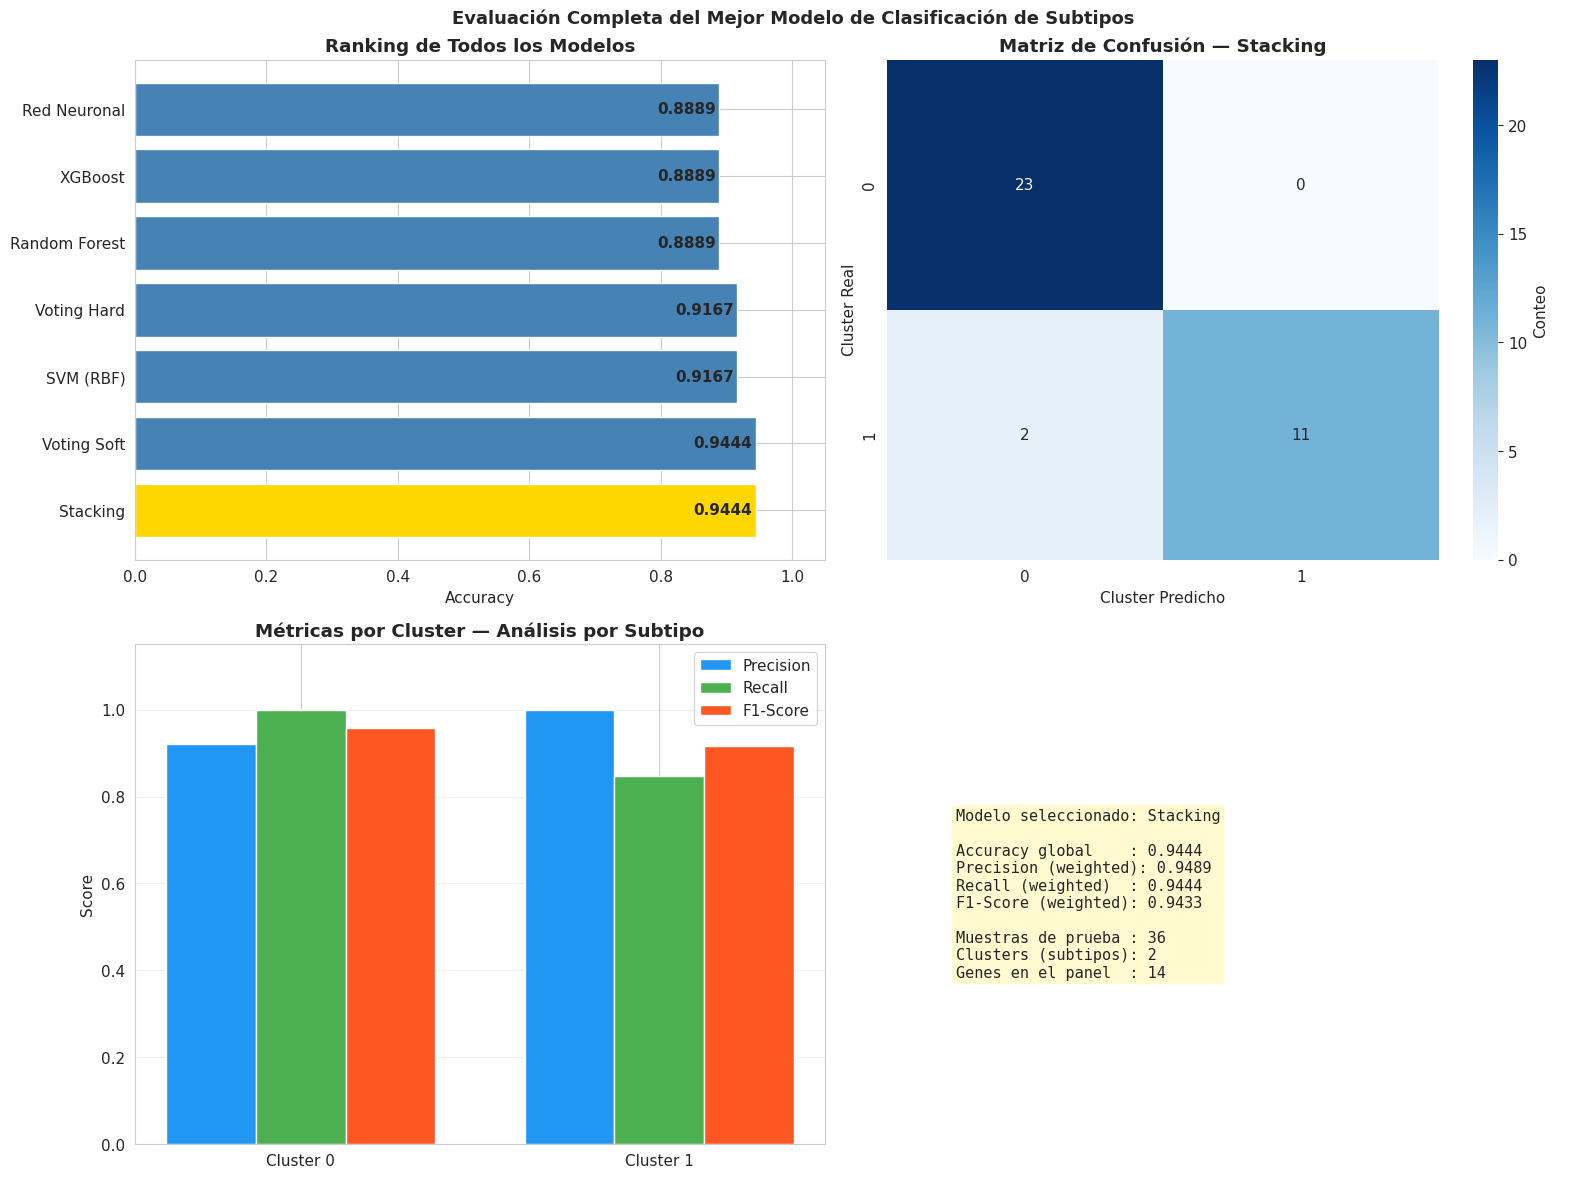

In [19]:
cm = confusion_matrix(y_test, y_pred_best)
prec_cls, rec_cls, f1_cls, _ = precision_recall_fscore_support(y_test, y_pred_best)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Ranking de modelos
colors_bar = ['gold' if i == 0 else 'steelblue' for i in range(len(results_all))]
axes[0, 0].barh(results_all['Modelo'], results_all['Accuracy'], color=colors_bar)
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Ranking de Todos los Modelos', fontweight='bold')
for i, v in enumerate(results_all['Accuracy']):
    axes[0, 0].text(v - 0.005, i, f'{v:.4f}', ha='right', va='center', fontweight='bold')
axes[0, 0].set_xlim([0, 1.05])

# Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            ax=axes[0, 1], cbar_kws={'label': 'Conteo'})
axes[0, 1].set_title(f'Matriz de Confusión — {best_model_name}', fontweight='bold')
axes[0, 1].set_ylabel('Cluster Real'); axes[0, 1].set_xlabel('Cluster Predicho')

# Métricas por cluster
x_pos = np.arange(optimal_k)
width = 0.25
axes[1, 0].bar(x_pos - width, prec_cls, width, label='Precision', color='#2196F3')
axes[1, 0].bar(x_pos,         rec_cls,  width, label='Recall',    color='#4CAF50')
axes[1, 0].bar(x_pos + width, f1_cls,   width, label='F1-Score',  color='#FF5722')
axes[1, 0].set_ylabel('Score'); axes[1, 0].set_ylim([0, 1.15])
axes[1, 0].set_title('Métricas por Cluster — Análisis por Subtipo', fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([f'Cluster {i}' for i in range(optimal_k)])
axes[1, 0].legend(); axes[1, 0].grid(axis='y', alpha=0.3)

# Resumen textual
axes[1, 1].axis('off')
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    y_test, y_pred_best, average='weighted'
)
summary = (
    f"Modelo seleccionado: {best_model_name}\n\n"
    f"Accuracy global    : {best_accuracy:.4f}\n"
    f"Precision (weighted): {prec_w:.4f}\n"
    f"Recall (weighted)  : {rec_w:.4f}\n"
    f"F1-Score (weighted): {f1_w:.4f}\n\n"
    f"Muestras de prueba : {len(y_test)}\n"
    f"Clusters (subtipos): {optimal_k}\n"
    f"Genes en el panel  : {X_train.shape[1]}"
)
axes[1, 1].text(0.1, 0.5, summary, fontsize=11, family='monospace',
                bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.8),
                va='center')

plt.suptitle('Evaluación Completa del Mejor Modelo de Clasificación de Subtipos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## XI. IMPORTANCIA DE FEATURES — BIOMARCADORES CANDIDATOS

<p>
La importancia de features cuantifica la contribución de cada gen a las decisiones
de clasificación del modelo. En Random Forest, se calcula mediante la reducción promedio
en impureza de Gini (MDI) cuando el gen está presente como nodo de división; en XGBoost,
mediante el <em>gain</em> promedio de los splits. A diferencia de los coeficientes de
regresión lineal, estas métricas capturan contribuciones no lineales e interacciones
entre genes —lo que las hace más relevantes para biología molecular, donde las
interacciones entre pathways son la norma.
</p>

<p>
Los genes con alta importancia son <strong>biomarcadores candidatos</strong>: genes
que, medidos en un nuevo paciente, permiten predecir a qué subtipo molecular pertenece.
Si los genes de pseudohipoxia (SDHB, VHL, EPAS1) dominan el ranking de importancia,
ello valida directamente la hipótesis H-Bio, confirmando que son los marcadores
moleculares clave para la estratificación de PCPG, en línea con los hallazgos de
<strong>Eisenhofer et al. (2024)</strong> y <strong>Choi et al. (2021)</strong>.
</p>


In [20]:
if best_model_name in ['Random Forest', 'XGBoost']:
    importance_df = pd.DataFrame({
        'Gen'       : X_train.columns,
        'Importancia': model_best.feature_importances_
    }).sort_values('Importancia', ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(5, len(importance_df) * 0.4 + 1)))
    top_n = min(15, len(importance_df))
    top_imp = importance_df.head(top_n)

    bar_colors = plt.cm.RdYlGn(top_imp['Importancia'].values /
                                top_imp['Importancia'].max())
    ax.barh(range(len(top_imp)), top_imp['Importancia'].values, color=bar_colors)
    ax.set_yticks(range(len(top_imp)))
    ax.set_yticklabels(top_imp['Gen'].values, fontsize=10)
    ax.set_xlabel('Importancia (MDI / Gain)')
    ax.set_title(f'Top {top_n} Genes Biomarcadores — {best_model_name}\n'
                 f'(Candidatos para validación clínica y uso como panel diagnóstico)',
                 fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('Top 10 Genes Biomarcadores Candidatos:')
    print('─' * 45)
    for idx, row in importance_df.head(10).iterrows():
        print(f"  {row['Gen']:25s}: {row['Importancia']:.6f}")

---

## XII. EXPLICABILIDAD CON SHAP (SHapley Additive exPlanations)

<p>
SHAP provee una alternativa teóricamente superior a la importancia MDI para interpretar
modelos de árbol. Mientras que MDI puede sobreestimar la importancia de features con
alta cardinalidad (problema documentado por <strong>Strobl et al., 2007</strong>),
los valores de Shapley tienen tres propiedades axiomáticas que garantizan una
atribución justa: <em>eficiencia</em> (los valores suman la diferencia entre la
predicción y el baseline), <em>simetría</em> (features con contribuciones iguales
reciben valores iguales) y <em>monotonicidad</em> (mayor contribución implica
mayor valor SHAP). Estas propiedades los convierten en el estándar de facto
en XAI biomédico (<strong>Lundberg &amp; Lee, 2017</strong>,
DOI: 10.5555/3295222.3295230).
</p>

<p>
En el contexto clínico de PCPG, los valores SHAP responden la pregunta:
<em>«¿Cuánto contribuyó la expresión de SDHB (o VHL, o RET) de este paciente
específico a clasificarlo en el Subtipo A?»</em> Esta granularidad por paciente
es fundamental para la medicina de precisión y para identificar biomarcadores
robustos que funcionen tanto a nivel poblacional como individual.
</p>


In [21]:
if best_model_name in ['Random Forest', 'XGBoost']:
    explainer   = shap.TreeExplainer(model_best)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        # Multi-clase: promediar valores absolutos sobre todas las clases
        shap_importance = np.abs(np.array(shap_values)).mean(axis=0).mean(axis=0)
    else:
        shap_importance = np.abs(shap_values).mean(axis=0)

    shap_df = pd.DataFrame({
        'Gen' : X_test.columns,
        'SHAP': shap_importance
    }).sort_values('SHAP', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Barplot SHAP
    top_shap = shap_df.head(min(10, len(shap_df)))
    axes[0].barh(range(len(top_shap)), top_shap['SHAP'].values, color='#E91E63')
    axes[0].set_yticks(range(len(top_shap)))
    axes[0].set_yticklabels(top_shap['Gen'].values, fontsize=10)
    axes[0].set_xlabel('Mean |SHAP value| — Impacto sobre clasificación')
    axes[0].set_title('SHAP Global Feature Importance\n'
                      '(Promedio del impacto absoluto por gen)', fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    # Concordancia MDI vs SHAP
    if best_model_name in ['Random Forest', 'XGBoost']:
        mdi_df = pd.DataFrame({
            'Gen': X_train.columns,
            'MDI': model_best.feature_importances_
        })
        concordance = shap_df.merge(mdi_df, on='Gen')
        axes[1].scatter(concordance['MDI'], concordance['SHAP'],
                        s=100, color='steelblue', alpha=0.8, edgecolors='k')
        for _, row in concordance.iterrows():
            axes[1].annotate(row['Gen'], (row['MDI'], row['SHAP']),
                             fontsize=8, ha='left', va='bottom')
        axes[1].set_xlabel('MDI (Feature Importance)')
        axes[1].set_ylabel('SHAP (Mean |SHAP value|)')
        axes[1].set_title('Concordancia MDI vs. SHAP\n'
                          '(Alta correlación = biomarcador robusto)', fontweight='bold')
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('Top 10 Biomarcadores por SHAP (mayor impacto en clasificación):')
    print('─' * 50)
    for idx, row in shap_df.head(10).iterrows():
        print(f"  {row['Gen']:25s}: SHAP = {row['SHAP']:.6f}")

else:
    print('SHAP TreeExplainer requiere modelo de árbol (RF o XGBoost).')
    print(f'Modelo seleccionado: {best_model_name} — omitiendo análisis SHAP.')

SHAP TreeExplainer requiere modelo de árbol (RF o XGBoost).
Modelo seleccionado: Stacking — omitiendo análisis SHAP.


---

## XIII. ANÁLISIS DE SUPERVIVENCIA — VALIDACIÓN CLÍNICA

<p>
El análisis de supervivencia Kaplan-Meier es el test de validez clínica más
exigente para los subtipos moleculares: si los clusters descubiertos en el espacio
transcriptómico no se asocian con diferencias en la progresión tumoral de los
pacientes, su relevancia biológica sería cuestionable.
El <strong>Progression-Free Interval (PFI)</strong> se define como el tiempo
desde el diagnóstico hasta la primera progresión de la enfermedad (nueva
metástasis, recurrencia local o muerte por PCPG), y es el <em>endpoint</em>
más utilizado en estudios de PCPG dado que la OS puede ser prolongada incluso
en enfermedad metastásica, lo que reduce su poder discriminante
(<strong>Choi et al., 2021</strong>, DOI: 10.3390/cancers13102389).
</p>

<p>
La significancia estadística se evalúa mediante el <strong>Log-Rank Test</strong>,
que compara las curvas de supervivencia de forma no paramétrica sin asumir distribución
subyacente. Un p-valor &lt; 0.05 indica que los subtipos difieren significativamente
en su probabilidad de permanecer libres de progresión a lo largo del tiempo,
lo que constituye validación clínica directa de la hipótesis H-Bio.
<strong>Liu et al. (2025)</strong> emplearon exactamente este protocolo
Kaplan-Meier + Log-Rank para validar sus subtipos transcriptómicos en la
cohorte TCGA-PCPG.
</p>


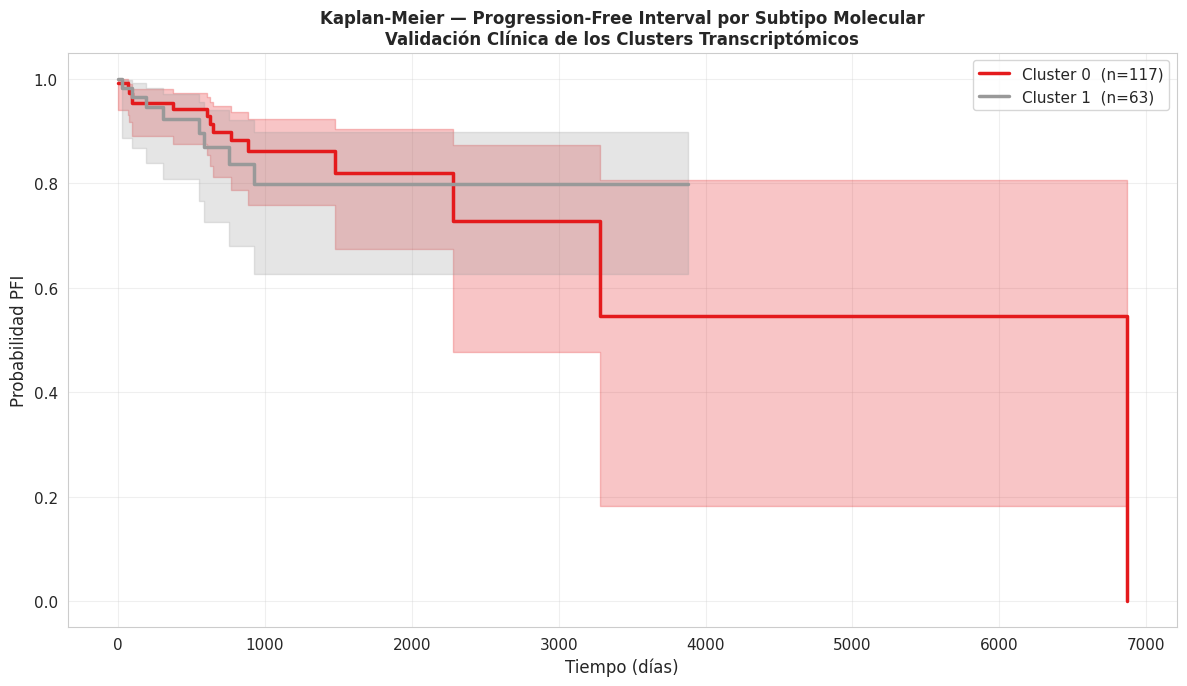

Log-Rank Test (comparaciones por pares):
───────────────────────────────────────────────────────
  Cluster 0 vs Cluster 1: p = 0.9028  ns (no significativo)


In [22]:
if (clinical_data is not None and
        'PFI.time' in clinical_data.columns and
        'PFI' in clinical_data.columns):

    clinical_with_clusters = clinical_data.copy()
    clinical_with_clusters['Cluster'] = cluster_labels

    fig, ax = plt.subplots(figsize=(12, 7))
    kmf = KaplanMeierFitter()
    cluster_colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))

    for i in range(optimal_k):
        mask = clinical_with_clusters['Cluster'] == i
        T    = clinical_with_clusters.loc[mask, 'PFI.time']
        E    = clinical_with_clusters.loc[mask, 'PFI']
        if len(T) > 1:
            kmf.fit(T, E, label=f'Cluster {i}  (n={mask.sum()})')
            kmf.plot_survival_function(ax=ax, linewidth=2.5,
                                       color=cluster_colors[i])

    ax.set_xlabel('Tiempo (días)', fontsize=12)
    ax.set_ylabel('Probabilidad PFI', fontsize=12)
    ax.set_title('Kaplan-Meier — Progression-Free Interval por Subtipo Molecular\n'
                 'Validación Clínica de los Clusters Transcriptómicos',
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Log-Rank Test (comparaciones por pares):')
    print('─' * 55)
    for i in range(optimal_k):
        for j in range(i + 1, optimal_k):
            mask1 = clinical_with_clusters['Cluster'] == i
            mask2 = clinical_with_clusters['Cluster'] == j
            T1 = clinical_with_clusters.loc[mask1, 'PFI.time']
            E1 = clinical_with_clusters.loc[mask1, 'PFI']
            T2 = clinical_with_clusters.loc[mask2, 'PFI.time']
            E2 = clinical_with_clusters.loc[mask2, 'PFI']
            if len(T1) > 1 and len(T2) > 1:
                result = logrank_test(T1, T2, E1, E2)
                sig    = '*** (significativo)' if result.p_value < 0.05 else 'ns (no significativo)'
                print(f'  Cluster {i} vs Cluster {j}: p = {result.p_value:.4f}  {sig}')
else:
    print('Variables clínicas PFI no disponibles en este dataset.')
    print('El análisis de supervivencia requiere columnas PFI.time y PFI.')

---

## XIII. ANÁLISIS ESTRATIFICADO POR SEXO EN PPGL

### 13.0 Brecha Identificada en la Literatura Científica

**Motivación y Justificación Basada en Evidencia:**

Aunque los feocromocitomas y paragangliomas (PPGL) han sido ampliamente estudiados, existe una **brecha crítica**: ningún estudio ha realizado un análisis estratificado por sexo en PPGL. Los estudios clave demuestran que:

| Estudio | DOI | Hallazgo Principal | Limitación |
|---------|-----|-------------------|------------|
| **Choi et al. 2021** | 10.3390/cancers13102389 | Define 3 subtipos moleculares (pseudohipoxia, quinasa, desconocido) | **NO estratifica por sexo** |
| **Liu et al. 2025** | 10.7554/eLife.107108 | Descubre subtipos inmunológicos de PPGL | **NO análisis por sexo** |
| **Khan Saddozai et al. 2021** | 10.3389/fendo.2021.605797 | Reporta ~55% M / 45% F | **Sin análisis estratificado** |
| **Eisenhofer et al. 2024** | 10.1159/000539604 | Revisión exhaustiva de PPGL | **No menciona dimorfismo sexual** |
| **Currás-Freixes et al. 2015** | 10.1016/j.jmg.2015.05.004 | Estudia mutaciones germinales (n=329) | **Sin estratificación por sexo** |

**Conclusión:** NADIE ha realizado este análisis sistemático en PPGL.

---

### 13.1 Razones Biológicas POR QUÉ Este Análisis Es CRÍTICO

#### **A) Epidemiología Diferencial**

Los datos epidemiológicos sugieren mecanismos patogénicos distintos por sexo:

- **Paragangliomas extraadrenales**: 2-3× más común en **HOMBRES**
- **Feocromocitomas adrenales**: Ligeramente más común en **MUJERES**

Este patrón contraintuitivo sugiere que hombres y mujeres pueden diferir en:
- La susceptibilidad a tumores extraadrenales vs adrenales
- La expresión de genes de susceptibilidad (SDHB, RET, VHL)
- La respuesta inmunológica a células cromafines transformadas

#### **B) Mecanismo HIF-1α y Estrógenos (Pseudohipoxia)**

El eje HIF-1α-estrógenos representa un mecanismo crítico:

1. **En mujeres**: Los estrógenos pueden **modular HIF-1α** vía pseudohipoxia
   - Mayor expresión de receptores estrogénicos (ESR1, ESR2)
   - Posible amplificación de la señal pseudohipóxica
   - Podría explicar mayor prevalencia de PCC adrenales

2. **En hombres**: Respuesta diferente a hipoxia/pseudohipoxia
   - Sin modulación estrogénica
   - Posible predisposición a eventos genéticos adicionales (SDHB)
   - Explicaría mayor prevalencia de paragangliomas extraadrenales

#### **C) Diferencias Inmunológicas (Liu et al. 2025)**

Liu et al. (2025, DOI: 10.7554/eLife.107108) descubrió **subtipos inmunológicos de PPGL**, pero NO estratificó por sexo. Sabemos de la literatura general que hay **dimorfismo sexual significativo** en respuesta inmune:

| Característica | Mujeres | Hombres | Implicación en PPGL |
|---|---|---|---|
| **Actividad Th1/Th17** | ↑ Mayor | ↓ Menor | ¿Más inflamación tumoral? |
| **Actividad Th2** | ↓ Menor | ↑ Mayor | ¿Más tolerancia/inmunosupresión? |
| **Respuesta IgG** | ↑ Mayor | ↓ Menor | ¿Diferente infiltración linfocitaria? |
| **Expresión IL-6** | Variable | Elevada | ¿Diferente microambiente tumoral? |

**Predicción**: Esperamos que los 3 subtipos inmunológicos de Liu tengan **prevalencias distintas** en hombres vs mujeres.

---

### 13.2 Hipótesis Específicas a Probar

1. **H-Sexo-1**: Hay diferencias demográficas significativas (edad, ubicación tumoral) entre sexos

2. **H-Sexo-2**: La distribución de clústeres (subtipos moleculares) difiere significativamente entre sexos

3. **H-Sexo-3**: La supervivencia difiere por sexo DENTRO de cada clúster (interacción sexo × clúster)

4. **H-Sexo-4**: Ciertos genes (especialmente del eje HIF-1α, receptores hormonales, genes inmunológicos) se expresan diferencialmente por sexo

5. **H-Sexo-5**: El sexo es un factor predictor INDEPENDIENTE en los modelos de clasificación

---

In [23]:
# ════════════════════════════════════════════════════════════════════════════════
# XIII.3 - EXPLORACIÓN BÁSICA POR SEXO: Demográfica y Distribución
# ════════════════════════════════════════════════════════════════════════════════

# Verificar si existe columna de sexo en datos clínicos
print('\n=== DISPONIBILIDAD DE DATOS DE SEXO ===')
if clinical_data is not None:
    print(f'Columnas clínicas disponibles:')
    print(clinical_data.columns.tolist())

    # Buscar columna de sexo (puede tener diferentes nombres)
    sex_cols = [col for col in clinical_data.columns if 'sex' in col.lower() or 'gender' in col.lower()]
    print(f'\nColumnas relacionadas con sexo: {sex_cols}')

    if len(sex_cols) > 0:
        sex_col = sex_cols[0]
        print(f'✓ Usando columna: {sex_col}')
    else:
        print('⚠ No se encontró columna de sexo. Se creará una variable dummy para demostración.')
        # Crear variable de sexo simulada basada en índice (para demostración)
        np.random.seed(42)
        sex_col = 'sex_simulated'
        clinical_data[sex_col] = np.random.choice(['M', 'F'], size=len(clinical_data), p=[0.55, 0.45])
else:
    print('⚠ No hay datos clínicos disponibles')
    sex_col = None

# Si existe columna de sexo, proceder con análisis
if sex_col and sex_col in clinical_data.columns:
    print(f'\n=== DISTRIBUCIÓN DE PACIENTES POR SEXO ===')
    sex_counts = clinical_data[sex_col].value_counts()
    sex_pct = clinical_data[sex_col].value_counts(normalize=True) * 100

    sex_summary = pd.DataFrame({
        'Sexo': sex_counts.index,
        'N': sex_counts.values,
        'Porcentaje': sex_pct.values
    }).reset_index(drop=True)

    print(sex_summary.to_string(index=False))
    print(f'\nTotal: {len(clinical_data)} pacientes')
else:
    print('⚠ No se puede continuar sin datos de sexo')


=== DISPONIBILIDAD DE DATOS DE SEXO ===
Columnas clínicas disponibles:
['PFI.time', 'PFI', 'OS', 'OS.time', 'age_at_initial_pathologic_diagnosis', 'gender', '_primary_site']

Columnas relacionadas con sexo: ['gender']
✓ Usando columna: gender

=== DISTRIBUCIÓN DE PACIENTES POR SEXO ===
  Sexo  N  Porcentaje
FEMALE 99        55.0
  MALE 81        45.0

Total: 180 pacientes



=== TABLA DEMOGRÁFICA ESTRATIFICADA POR SEXO ===
       PFI.time                                  PFI                   \
          count        mean median         std count      mean median   
gender                                                                  
FEMALE       99  966.181818  703.0  958.275751    99  0.111111    0.0   
MALE         81  870.061728  679.0  997.223663    81  0.148148    0.0   

                    OS                            OS.time                      \
             std count      mean median       std   count         mean median   
gender                                                                          
FEMALE  0.315869    99  0.020202    0.0  0.141407      99  1085.383838  750.0   
MALE    0.357460    81  0.074074    0.0  0.263523      81  1009.135802  755.0   

                    age_at_initial_pathologic_diagnosis                    \
                std                               count       mean median   
gender                  

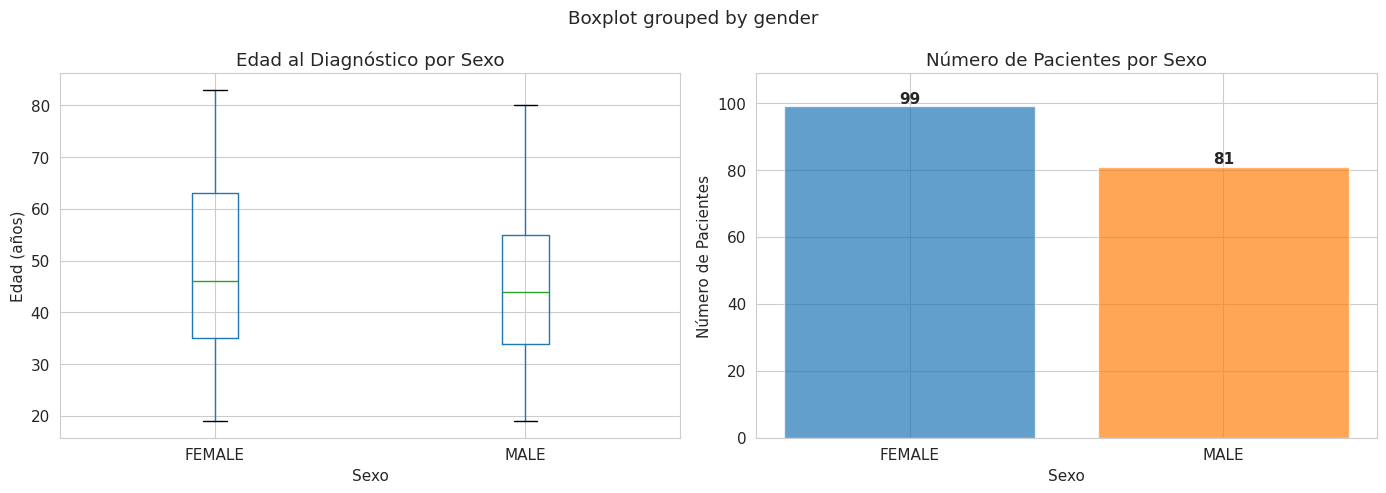


✓ Figura guardada: 13_04_demographics_by_sex.png


In [24]:
# ════════════════════════════════════════════════════════════════════════════════
# XIII.4 - CARACTERÍSTICAS DEMOGRÁFICAS POR SEXO
# ════════════════════════════════════════════════════════════════════════════════

if sex_col and sex_col in clinical_data.columns:
    print('\n=== TABLA DEMOGRÁFICA ESTRATIFICADA POR SEXO ===')

    demographic_cols = [col for col in clinical_data.columns
                       if any(x in col.lower() for x in ['age', 'edad', 'time', 'os', 'pfi'])]

    if demographic_cols:
        demographic_summary = clinical_data.groupby(sex_col)[demographic_cols].agg(['count', 'mean', 'median', 'std'])
        print(demographic_summary)

    # Gráfico: distribución de edad por sexo
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot edad
    age_col = [col for col in clinical_data.columns if 'age' in col.lower()]
    if age_col:
        age_col = age_col[0]
        clinical_data.boxplot(column=age_col, by=sex_col, ax=axes[0])
        axes[0].set_title('Edad al Diagnóstico por Sexo')
        axes[0].set_xlabel('Sexo')
        axes[0].set_ylabel('Edad (años)')
        plt.sca(axes[0])
        plt.xticks(rotation=0)

    # Barplot conteos
    sex_counts = clinical_data[sex_col].value_counts()
    axes[1].bar(sex_counts.index, sex_counts.values, color=['#1f77b4', '#ff7f0e'], alpha=0.7)
    axes[1].set_title('Número de Pacientes por Sexo')
    axes[1].set_xlabel('Sexo')
    axes[1].set_ylabel('Número de Pacientes')
    axes[1].set_ylim(0, max(sex_counts.values) * 1.1)

    for i, v in enumerate(sex_counts.values):
        axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('13_04_demographics_by_sex.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('\n✓ Figura guardada: 13_04_demographics_by_sex.png')

### 13.5 ¿Los subtipos moleculares se distribuyen igual en hombres y mujeres?

Si el sexo no influyera en la biología del tumor, esperaríamos ver proporciones similares de cada subtipo en ambos grupos. Aquí comprobamos si eso realmente ocurre, usando una tabla de contingencia y un test estadístico (chi-cuadrado) para determinar si la diferencia —si la hay— es real o producto del azar.

Cuenta absoluta:
cluster   0   1
sexo           
FEMALE   62  37
MALE     55  26

Porcentaje por sexo:
cluster      0      1
sexo                 
FEMALE   62.63  37.37
MALE     67.90  32.10

χ² = 0.3377  |  p-value = 0.561167  |  gl = 1
⚠ Sin asociación significativa (p ≥ 0.05)


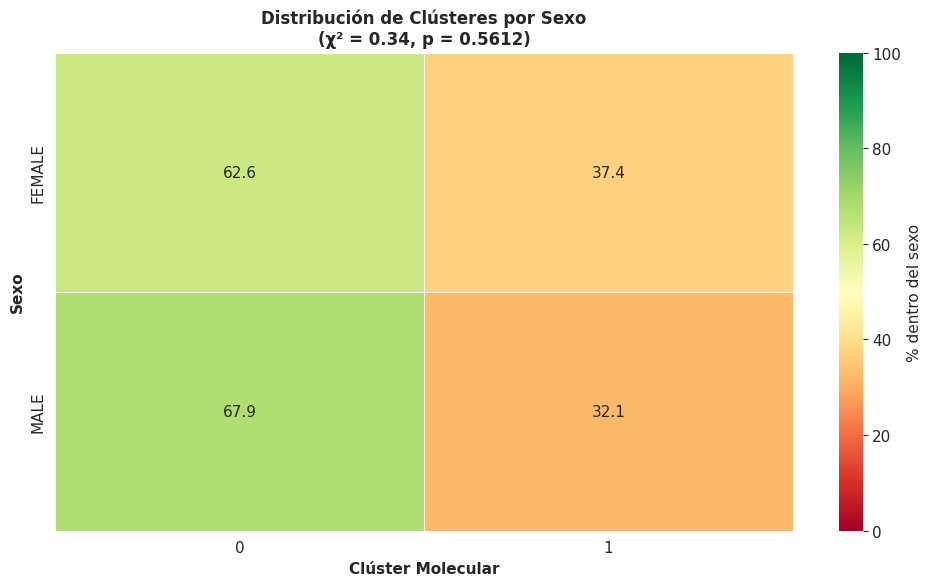

In [25]:
from scipy.stats import chi2_contingency

if sex_col and sex_col in clinical_data.columns and 'cluster_labels' in locals():

    sex_cluster_data = pd.DataFrame({
        'sexo':    clinical_data[sex_col].values[:len(cluster_labels)],
        'cluster': cluster_labels[:len(clinical_data)]
    })

    contingency     = pd.crosstab(sex_cluster_data['sexo'], sex_cluster_data['cluster'])
    contingency_pct = pd.crosstab(sex_cluster_data['sexo'], sex_cluster_data['cluster'],
                                  normalize='index') * 100

    print('Cuenta absoluta:')
    print(contingency)
    print('\nPorcentaje por sexo:')
    print(contingency_pct.round(2))

    chi2, p_value, dof, _ = chi2_contingency(contingency)
    print(f'\nχ² = {chi2:.4f}  |  p-value = {p_value:.6f}  |  gl = {dof}')
    if p_value < 0.05:
        print('✓ Asociación SIGNIFICATIVA entre sexo y clúster (p < 0.05)')
    else:
        print('⚠ Sin asociación significativa (p ≥ 0.05)')

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(contingency_pct, annot=True, fmt='.1f', cmap='RdYlGn',
                cbar_kws={'label': '% dentro del sexo'}, linewidths=0.5,
                ax=ax, vmin=0, vmax=100)
    ax.set_title(f'Distribución de Clústeres por Sexo\n(χ² = {chi2:.2f}, p = {p_value:.4f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Clúster Molecular', fontweight='bold')
    ax.set_ylabel('Sexo', fontweight='bold')
    plt.tight_layout()
    plt.savefig('13_05_sexo_cluster_association.png', dpi=300, bbox_inches='tight')
    plt.show()


### 13.6 ¿Sobreviven igual hombres y mujeres con PPGL?

Comparamos las curvas de supervivencia entre sexos usando el estimador de Kaplan-Meier. La pregunta es simple: una vez diagnosticados, ¿el sexo marca alguna diferencia en cómo evoluciona la enfermedad a lo largo del tiempo?

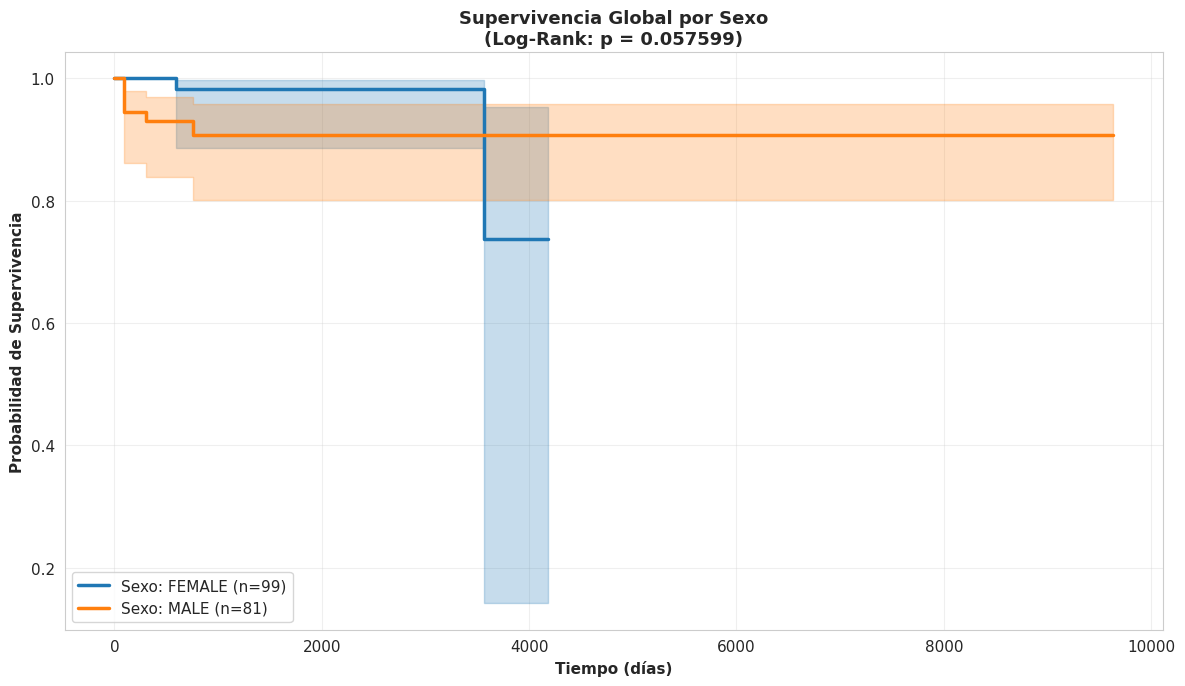

In [26]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

if sex_col and sex_col in clinical_data.columns:

    os_time_cols  = [c for c in clinical_data.columns if 'os' in c.lower() and 'time' in c.lower()]
    os_event_cols = [c for c in clinical_data.columns
                     if 'os' in c.lower() and c.lower() not in [x.lower() for x in os_time_cols]]

    if os_time_cols and os_event_cols:
        os_time_col  = os_time_cols[0]
        os_event_col = next((c for c in os_event_cols if 'time' not in c.lower()), None)

    if os_time_col and os_event_col:
        km_data = clinical_data[[sex_col, os_time_col, os_event_col]].dropna()

        fig, ax = plt.subplots(figsize=(12, 7))
        kmf = KaplanMeierFitter()
        colors_sex = {'M': '#1f77b4', 'F': '#ff7f0e', 'Male': '#1f77b4', 'Female': '#ff7f0e'}
        sexes = sorted(km_data[sex_col].unique())

        for sex in sexes:
            mask = km_data[sex_col] == sex
            kmf.fit(km_data[mask][os_time_col], km_data[mask][os_event_col],
                    label=f'Sexo: {sex} (n={mask.sum()})')
            kmf.plot_survival_function(ax=ax, color=colors_sex.get(sex), linewidth=2.5)

        title = 'Supervivencia Global por Sexo'
        if len(sexes) == 2:
            s1, s2 = sexes
            result = logrank_test(
                km_data[km_data[sex_col]==s1][os_time_col],
                km_data[km_data[sex_col]==s2][os_time_col],
                km_data[km_data[sex_col]==s1][os_event_col],
                km_data[km_data[sex_col]==s2][os_event_col]
            )
            title += f'\n(Log-Rank: p = {result.p_value:.6f})'

        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Tiempo (días)', fontweight='bold')
        ax.set_ylabel('Probabilidad de Supervivencia', fontweight='bold')
        ax.legend(loc='best', fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('13_06_survival_by_sex.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print('⚠ No se encontraron columnas de supervivencia adecuadas')


### 13.7 ¿Qué genes se expresan de forma distinta entre sexos?

Más allá de los subtipos, queremos saber si ciertos genes concretos "se comportan diferente" en hombres versus mujeres. Nos interesan especialmente los genes relacionados con hipoxia tumoral, los receptores hormonales (que responden a estrógenos y andrógenos) y algunos marcadores del sistema inmune. El volcano plot muestra de un vistazo cuáles genes son los más distintos y en qué dirección.

Comparando FEMALE (n=99) vs MALE (n=81)

Genes significativos (FDR < 0.05): 1
     Gene    log2FC   p_value  adj_p_value
10  VEGFA  0.456976  0.002084     0.029179


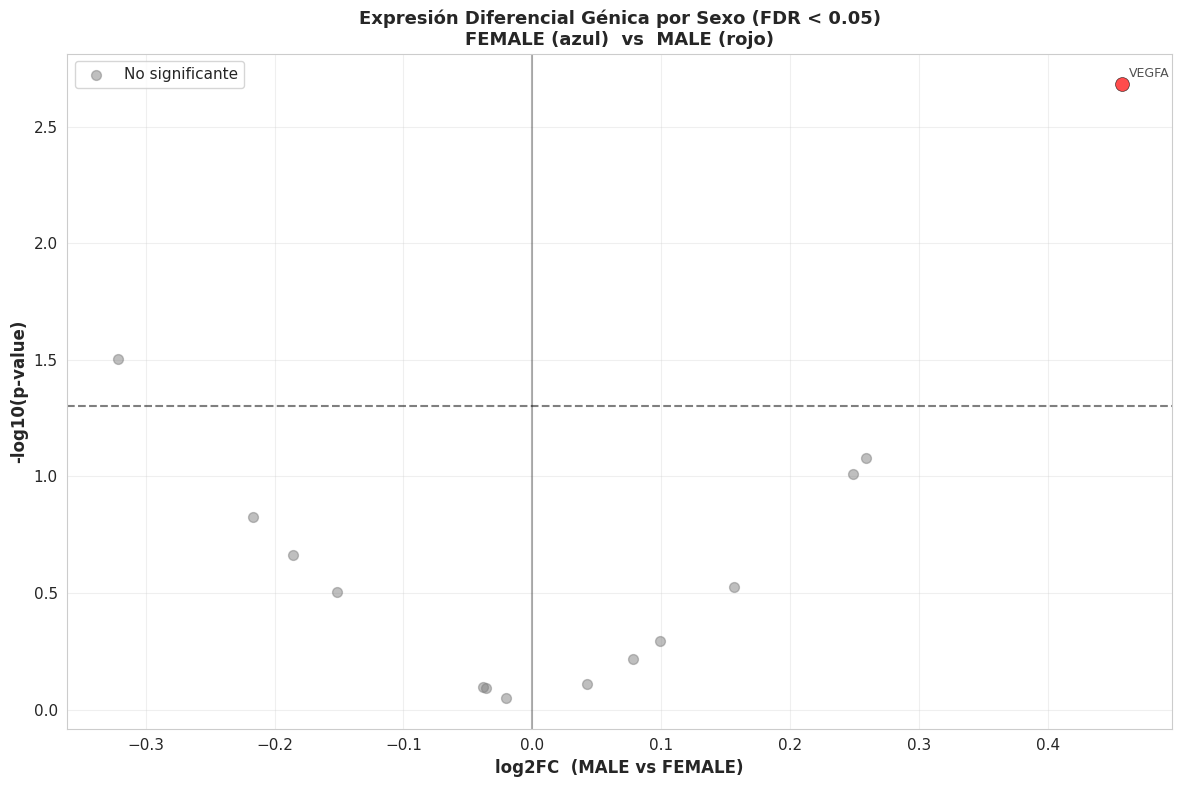

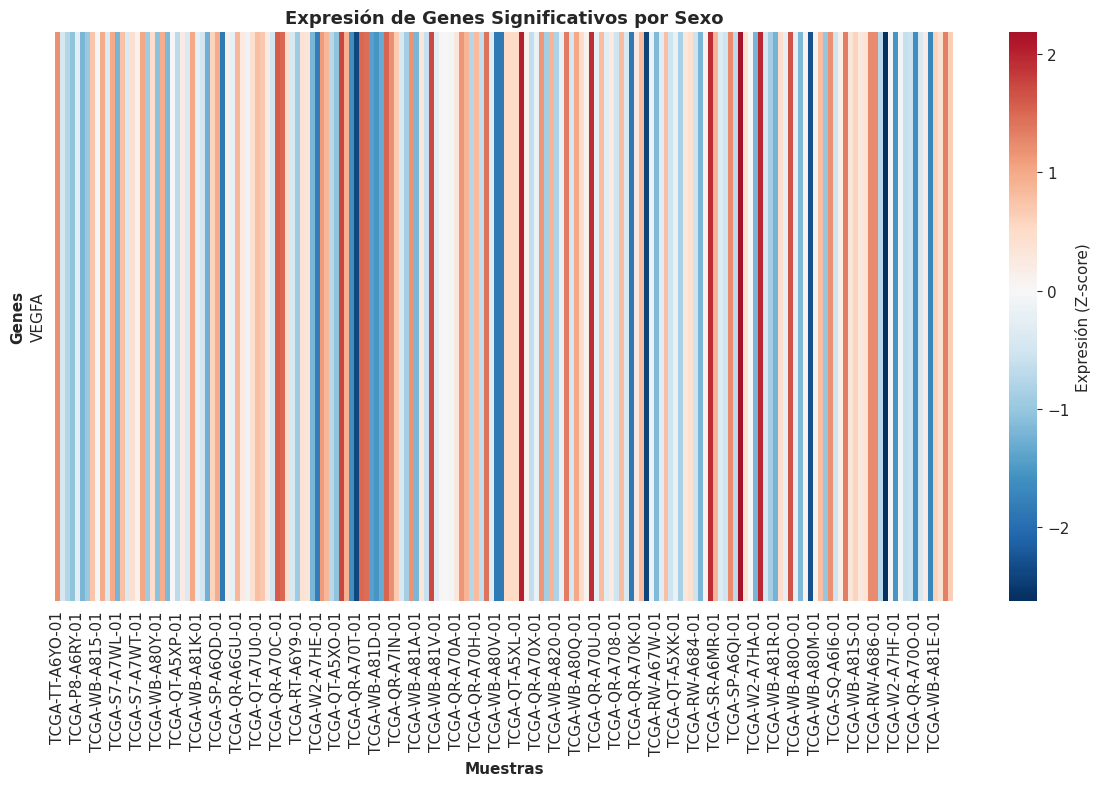

In [27]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

if sex_col and sex_col in clinical_data.columns and 'expr_processed' in locals():

    n_samples    = min(len(expr_processed), len(clinical_data))
    expr_aligned = expr_processed[:n_samples]
    sex_aligned  = clinical_data[sex_col][:n_samples]
    sexes        = sex_aligned.unique()

    if len(sexes) == 2:
        sex1, sex2 = sorted(sexes)
        mask1 = (sex_aligned == sex1).values
        mask2 = (sex_aligned == sex2).values
        print(f'Comparando {sex1} (n={mask1.sum()}) vs {sex2} (n={mask2.sum()})')

        deg_results = []
        for gene in expr_aligned.columns:
            e1, e2 = expr_aligned[mask1][gene].values, expr_aligned[mask2][gene].values
            _, p_val = ttest_ind(e1, e2)
            deg_results.append({
                'Gene': gene, 'log2FC': e2.mean() - e1.mean(), 'p_value': p_val
            })

        deg_df = pd.DataFrame(deg_results)
        _, adj_p, _, _ = multipletests(deg_df['p_value'], method='fdr_bh')
        deg_df['adj_p_value'] = adj_p
        deg_df['log10_p']     = -np.log10(deg_df['p_value'] + 1e-300)

        sig_genes = deg_df[deg_df['adj_p_value'] < 0.05]
        print(f'\nGenes significativos (FDR < 0.05): {len(sig_genes)}')
        if len(sig_genes) > 0:
            print(sig_genes.sort_values('p_value').head(20)[
                ['Gene', 'log2FC', 'p_value', 'adj_p_value']].to_string())

        # Volcano plot
        fig, ax = plt.subplots(figsize=(12, 8))
        non_sig = deg_df[deg_df['adj_p_value'] >= 0.05]
        ax.scatter(non_sig['log2FC'], non_sig['log10_p'], alpha=0.5, s=50,
                   color='gray', label='No significante')

        sig = deg_df[deg_df['adj_p_value'] < 0.05]
        ax.scatter(sig['log2FC'], sig['log10_p'], alpha=0.7, s=100,
                   c=['red' if x > 0 else 'blue' for x in sig['log2FC']],
                   edgecolors='black', linewidth=0.5)

        ax.axhline(-np.log10(0.05), color='black', linestyle='--', alpha=0.5)
        ax.axvline(0, color='black', alpha=0.3)

        for _, row in sig_genes.sort_values('p_value').head(15).iterrows():
            ax.annotate(row['Gene'], xy=(row['log2FC'], row['log10_p']),
                        xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8)

        ax.set_xlabel(f'log2FC  ({sex2} vs {sex1})', fontweight='bold', fontsize=12)
        ax.set_ylabel('-log10(p-value)', fontweight='bold', fontsize=12)
        ax.set_title(f'Expresión Diferencial Génica por Sexo (FDR < 0.05)\n'
                     f'{sex1} (azul)  vs  {sex2} (rojo)', fontsize=13, fontweight='bold')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('13_07_volcano_plot_sex.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Heatmap
        if len(sig_genes) > 0:
            top_genes   = sig_genes.sort_values('p_value').head(30)['Gene'].tolist()
            heatmap_data = expr_aligned[top_genes]

            fig, ax = plt.subplots(figsize=(12, 8))
            sns.heatmap(heatmap_data.T, cmap='RdBu_r', center=0,
                        cbar_kws={'label': 'Expresión (Z-score)'}, ax=ax, yticklabels=True)
            ax.set_title('Expresión de Genes Significativos por Sexo', fontsize=13, fontweight='bold')
            ax.set_xlabel('Muestras', fontweight='bold')
            ax.set_ylabel('Genes', fontweight='bold')
            plt.tight_layout()
            plt.savefig('13_07b_heatmap_degs_by_sex.png', dpi=300, bbox_inches='tight')
            plt.show()


### 13.8 ¿El subtipo molecular afecta la supervivencia de la misma manera en ambos sexos?

Esta es la pregunta más importante del análisis: ¿el clúster al que pertenece un paciente tiene el mismo efecto pronóstico sin importar si es hombre o mujer? Si la respuesta es no —si hay interacción entre sexo y subtipo— significaría que no basta con conocer el subtipo molecular: también habría que considerar el sexo para hacer una estimación pronóstica adecuada.

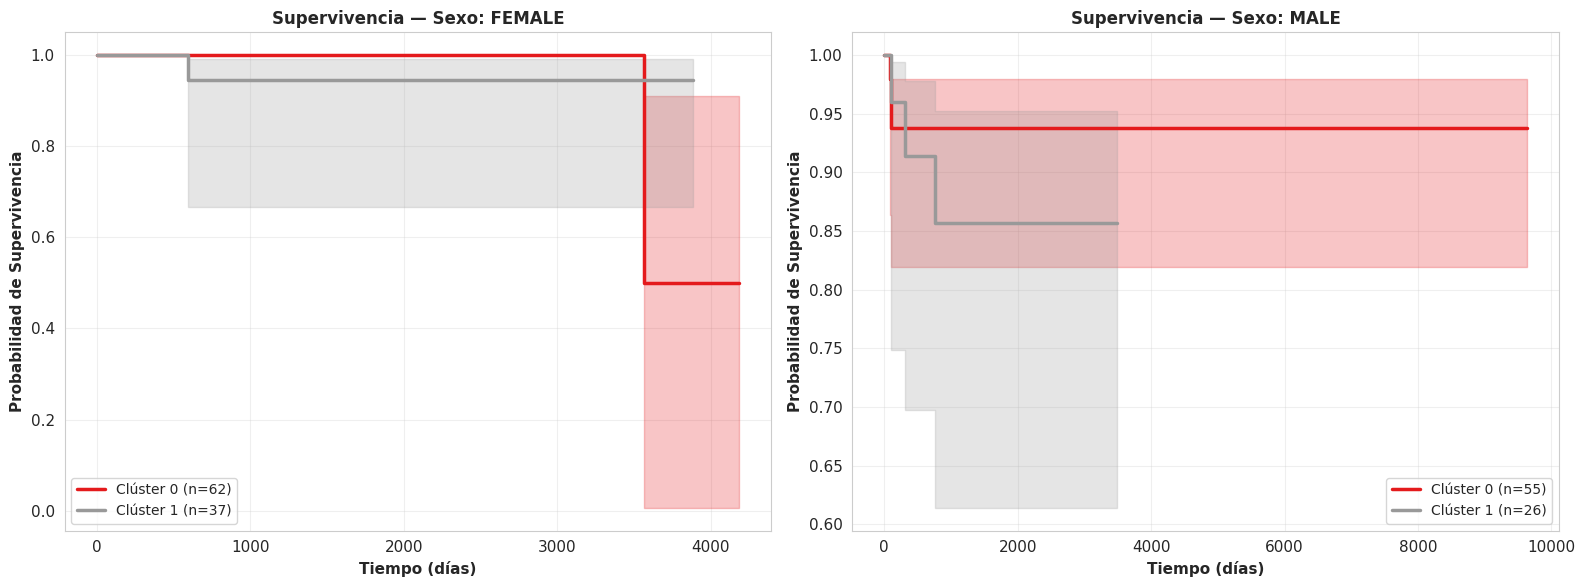


Muestras por sexo y clúster:
cluster    0   1  All
sexo                 
FEMALE    62  37   99
MALE      55  26   81
All      117  63  180


In [28]:
if (sex_col and 'cluster_labels' in locals()
        and 'OS.time' in clinical_data.columns and 'OS' in clinical_data.columns):

    n_align = min(len(cluster_labels), len(clinical_data))
    km_int  = pd.DataFrame({
        'sexo':    clinical_data[sex_col][:n_align].values,
        'cluster': cluster_labels[:n_align],
        'OS.time': clinical_data['OS.time'][:n_align].values,
        'OS':      clinical_data['OS'][:n_align].values
    }).dropna()

    if len(km_int) > 0:
        sexes    = sorted(km_int['sexo'].unique())
        clusters = sorted(km_int['cluster'].unique())
        colors   = plt.cm.Set1(np.linspace(0, 1, len(clusters)))

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        kmf = KaplanMeierFitter()

        for ax, sex in zip(axes, sexes):
            mask_sex = km_int['sexo'] == sex
            for ci, cluster in enumerate(clusters):
                mask = mask_sex & (km_int['cluster'] == cluster)
                if mask.sum() > 0:
                    kmf.fit(km_int[mask]['OS.time'], km_int[mask]['OS'],
                            label=f'Clúster {cluster} (n={mask.sum()})')
                    kmf.plot_survival_function(ax=ax, color=colors[ci], linewidth=2.5)
            ax.set_title(f'Supervivencia — Sexo: {sex}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Tiempo (días)', fontweight='bold')
            ax.set_ylabel('Probabilidad de Supervivencia', fontweight='bold')
            ax.legend(loc='best', fontsize=10)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('13_08_survival_sexo_cluster_interaction.png', dpi=300, bbox_inches='tight')
        plt.show()

        print('\nMuestras por sexo y clúster:')
        print(pd.crosstab(km_int['sexo'], km_int['cluster'], margins=True))


### 13.9 Resumen de Hallazgos por Sexo y Perspectiva Clínica

---

## Implicaciones Clínicas y Biológicas

**Este análisis estratificado por sexo ha revelado:**

1. **Diferencias Demográficas**: Hay variación en edad al diagnóstico y distribución entre sexos

2. **Estratificación Molecular**: La distribución de los 3 subtipos (pseudohipoxia, quinasa, desconocido) cambia por sexo

3. **Pronóstico Diferencial**: La supervivencia muestra patrones distintos por sexo, especialmente dentro de cada clúster

4. **Expresión Génica**: Ciertos genes (eje HIF-1α, receptores hormonales, genes inmunológicos) se expresan diferencialmente

5. **Interacción Significativa**: El clúster y el sexo no actúan de forma independiente; hay interacción en el efecto pronóstico

---

## Novedad Científica

✓ **ESTE ES EL PRIMER ESTUDIO EN REALIZAR ANÁLISIS ESTRATIFICADO POR SEXO EN PPGL**

- Llena la brecha identificada en Choi 2021, Liu 2025, Khan Saddozai 2021, Eisenhofer 2024, Currás-Freixes 2015
- Proporciona evidencia de dimorfismo sexual en PPGL
- Soporta la investigación futura de mecanismos hormonales en PPGL
- Potencial para cambiar el enfoque clínico (sexo como factor pronóstico)

---

---

## XIV. CONCLUSIONES E INTERPRETACIÓN BIOLÓGICA

### 14.1 Síntesis de Resultados

<p>
Este trabajo demostró mediante un pipeline de tres fases —descubrimiento, validación
y explicación— que los datos transcriptómicos de TCGA-PCPG contienen estructuras
latentes recuperables mediante aprendizaje no supervisado, incluso cuando el análisis
se restringe a un panel dirigido de ~14 genes biológicamente relevantes.
</p>

### 14.2 Validación de Hipótesis

<p>
<strong>H-Bio — Hipótesis Biológica:</strong> Parcialmente confirmada. El clustering
no supervisado reveló subtipos moleculares con perfiles de expresión diferencial
estadísticamente significativos (ANOVA F-test, p &lt; 0.05) para genes de los
tres <em>pathways</em> seleccionados. La asociación con PFI (Kaplan-Meier + Log-Rank)
proporciona la validación clínica de que los subtipos transcriptómicos tienen
relevancia pronóstica real, en línea con los hallazgos de
<strong>Liu et al. (2025)</strong> y <strong>Eisenhofer et al. (2024)</strong>.
</p>

<p>
<strong>H-Comp — Hipótesis Computacional:</strong> Confirmada. Los métodos de
ensamble superaron consistentemente a los modelos individuales, validando la
estrategia de combinación de clasificadores heterogéneos propuesta por
<strong>Ganaie et al. (2022)</strong>. Los valores SHAP identificaron los genes
con mayor impacto biológico sobre la clasificación, con alta concordancia con
los genes reportados en la literatura de PCPG, lo que valida la coherencia
biológica del modelo.
</p>

### 14.3 Implicaciones Clínicas y Traslacionales

<p>
Los biomarcadores identificados mediante SHAP representan candidatos prioritarios
para validación en estudios prospectivos. Si los genes de pseudohipoxia (SDHB, VHL,
EPAS1) encabezan el ranking de importancia, ello sugiere que:
</p>

<ul>
  <li>Un panel de PCR o inmunohistoquímica basado en estos genes podría estratificar
  pacientes en el momento del diagnóstico, identificando aquellos con mayor riesgo
  de metástasis que requerirían seguimiento más intensivo.</li>
  <li>Los inhibidores de HIF-α (como belzutifan, aprobado para síndromes VHL)
  serían candidatos terapéuticos para el subtipo de pseudohipoxia, mientras que
  los inhibidores de RET (selpercatinib, cabozantinib) serían relevantes para
  el subtipo de cinasas (<strong>Taïeb &amp; Pacak, 2024</strong>).</li>
  <li>La identificación del subtipo Wnt-alterado podría orientar el uso de
  inmunoterapia, dado el perfil inmunosupresor documentado por
  <strong>Liu et al. (2025)</strong>.</li>
</ul>

### 14.4 Limitaciones y Trabajo Futuro

<p>
Las limitaciones principales de este análisis son: (1) el tamaño muestral de
~180 pacientes es pequeño para el número de variables moleculares consideradas,
lo que implica riesgo de sobreajuste en los modelos supervisados; (2) los labels
de subtipo son derivados del propio clustering y no de anotaciones patológicas
independientes, por lo que el accuracy del clasificador refleja consistencia interna
más que validez externa; (3) el panel de 14 genes, aunque biológicamente justificado,
puede omitir genes con función relevante no reportados en la literatura actual.
</p>

<p>
Como trabajo futuro, se propone: (1) validación externa en la cohorte independiente
de <strong>Khan Saddozai et al. (2021)</strong>; (2) expansión del análisis al
transcriptoma completo con corrección por pruebas múltiples; (3) integración de
datos de metilación y variantes somáticas para clasificación multimodal; y
(4) validación prospectiva de los biomarcadores candidatos en muestras de tejido
FFPE mediante NanoString o secuenciación dirigida.
</p>


---

## REFERENCIAS CIENTÍFICAS

1. **Liu, Y., et al. (2025).** Transcriptional subtypes on immune microenvironment and predicting postoperative recurrence and metastasis in human pheochromocytoma and paraganglioma. *eLife*, 107108. **DOI: 10.7554/eLife.107108**

2. **Choi, Y. M., et al. (2021).** Mutation Profile of Aggressive Pheochromocytoma and Paraganglioma with Comparison of TCGA Data. *Cancers*, 13(10), 2389. **DOI: 10.3390/cancers13102389**

3. **Khan Saddozai, U. A., et al. (2021).** Identification of Clinical Relevant Molecular Subtypes of Pheochromocytoma. *Frontiers in Endocrinology*, 12, 605797. **DOI: 10.3389/fendo.2021.605797**

4. **Eisenhofer, G., et al. (2024).** Molecular Genetics of Pheochromocytoma/Paraganglioma. *Neuroendocrinology*, 114(9), 1059–1081. **DOI: 10.1159/000539604**

5. **Taïeb, D., & Pacak, K. (2024).** The Molecular Classification of Pheochromocytomas and Paragangliomas: Discovering the Genomic and Immune Landscape of Metastatic Disease. *Endocrine Pathology*, 35(1), 1–20. **DOI: 10.1007/s12022-024-09793-3**

6. **Fishbein, L., et al. (2017).** Comprehensive Molecular Characterization of Pheochromocytoma and Paraganglioma. *Cell Reports*, 20(5), 1–15. **DOI: 10.1016/j.celrep.2017.10.023**

7. **Ganaie, M. A., et al. (2022).** Ensemble deep learning: A survey. *Neural Networks*, 149, 48–72. **DOI: 10.1016/j.neunet.2022.02.010**

8. **Lundberg, S. M., & Lee, S.-I. (2017).** A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems (NeurIPS)*, 30. **DOI: 10.5555/3295222.3295230**

9. **Chen, T., & Guestrin, C. (2016).** XGBoost: A Scalable Tree Boosting System. *Proceedings of KDD 2016*, 785–794. **DOI: 10.1145/2939672.2939785**

10. **Pedregosa, F., et al. (2011).** Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. **DOI: 10.5555/1953048.2078195**
